# Lecture 4: Sentiment Analysis with Traditional Approaches

Sentiment analysis is a fundamental natural language processing task that aims to determine the valence or emotional opinion expressed in text. In this notebook, we will explore two major approaches to sentiment analysis in Python:

**1. Lexicon-based approaches:**

We begin by implementing sentiment analysis using predefined dictionaries of words with associated sentiment scores. You'll learn to:
- Build a manual sentiment pipeline from an existing lexicon to understand the core concepts,
- Apply popular ready-to-use packages including VADER (optimized for social media), TextBlob (general-purpose sentiment analysis), and NRClex (emotion and sentiment lexicons).

**2. Machine learning approaches:**

Next, we explore data-driven methods that learn sentiment patterns from labeled examples. We'll cover:
- Traditional feature-based models using lexical features (bag-of-words, TF-IDF, LSI),
- Basic embedding-based approaches using Doc2Vec for document representation.


## Lexicon-based Approach

### Data Collection from Mastodon

To demonstrate sentiment analysis, we'll first collect real social media data from Mastodon. We'll search for posts containing the hashtag **#AI**, a hot topic that generates diverse opinions and emotional responses, making it ideal for sentiment analysis.

Mastodon contains a mix of languages. Since most lexicons work best with English text, we'll filter for English toots only.

In [6]:
# Import required libraries
from mastodon import Mastodon
import pandas as pd
from bs4 import BeautifulSoup
import sys

# Import Mastodon utility functions
sys.path.append('../../../Lecture1/Code/Examples')
from mastodon_utils import fetch_hashtag_toots, add_clean_content, filter_by_language, select_columns

# Initialize Mastodon client
from config import MASTODON_ACCESS_TOKEN, MASTODON_API_BASE_URL
mastodon = Mastodon(
    access_token=MASTODON_ACCESS_TOKEN,
    api_base_url=MASTODON_API_BASE_URL
)


In [7]:
# Search for toots with #AI hashtag using utility functions
hashtag = "AI"
max_toots = 500

# Fetch toots with automatic pagination
df_toots = fetch_hashtag_toots(mastodon, hashtag, max_toots=max_toots, verbose=False)

print(f"Retrieved {len(df_toots)} toots")

Retrieved 480 toots


In [8]:
# Clean HTML tags from content
df_toots = add_clean_content(df_toots)

# Filter for English language only (using Mastodon's language field)
df_toots = filter_by_language(df_toots, language='en', verbose=True)

# Select relevant columns (renames 'clean_content' to 'text')
df_toots = select_columns(df_toots, columns=['text', 'created_at'])

print(f"\nDataFrame shape after initial filtering: {df_toots.shape}")
df_toots.head()


Language filter ('en'):
  Before: 480 toots
  After: 275 toots (57.3%)

DataFrame shape after initial filtering: (275, 2)


,text,created_at
0,I just set up #pai on a fresh installation of ...,2026-02-12 13:34:41+00:00
1,Every AI creator is pushing VPS setups for Ope...,2026-02-12 13:34:38.285000+00:00
2,Introducing Sagents -- an open-source #ElixirL...,2026-02-12 13:31:25.666000+00:00
3,Looking to upgrade your career with an MBA? Di...,2026-02-12 13:28:12.559000+00:00
4,The AI experiment that shocked researchersEncr...,2026-02-12 13:23:20.744000+00:00


#### Additional Language Filtering

The Mastodon API's `language` field is not always accurate. To ensure we only analyze English text, we'll use `langdetect` library for more robust language detection. This library uses character n-gram models to identify the language of text with high accuracy.

Since sentiment lexicons work with English words, it is important to only keep the toots that matter. If other languages mught be present, some words might be wrongly interpreted by these English lexicons.

In [9]:
from langdetect import detect, LangDetectException

def detect_language(text):
    """
    Detect language of text using langdetect.
    Returns 'en' for English, other codes for other languages, or None if detection fails.
    """
    try:
        # Detect language (returns ISO 639-1 code like 'en', 'es', 'fr', etc.)
        return detect(text)
    except LangDetectException:
        # If detection fails (e.g., text too short or no alphabetic characters)
        return None

# Apply language detection to all toots
print("Detecting language for each toot...")
df_toots['detected_lang'] = df_toots['text'].apply(detect_language)

# Check language distribution
print("\nDetected language distribution:")
print(df_toots['detected_lang'].value_counts())

# Filter for English only based on detected language
initial_count = len(df_toots)
df_toots = df_toots[df_toots['detected_lang'] == 'en'].copy()
df_toots = df_toots.drop('detected_lang', axis=1).reset_index(drop=True)

print(f"\nAfter language detection filtering:")
print(f"  Before: {initial_count} toots")
print(f"  After: {len(df_toots)} toots ({len(df_toots)/initial_count*100:.1f}%)")
print(f"\nFinal dataset shape: {df_toots.shape}")


Detecting language for each toot...



Detected language distribution:
detected_lang
en    265
ko      3
ca      2
et      2
it      1
fr      1
nl      1
Name: count, dtype: int64

After language detection filtering:
  Before: 275 toots
  After: 265 toots (96.4%)

Final dataset shape: (265, 2)


### Using a Sentiment Lexicon

We'll use a comprehensive sentiment lexicon that rates words on three psychological dimensions:

- **VALENCE**: Emotional sentiment (negative to positive)
- **AROUSAL**: Emotional intensity or excitement (calm to excited)
- **DOMINANCE**: Sense of control or power (submissive to dominant)

Each dimension is originally rated on a scale from 1 to 9.

In [10]:
# Load the sentiment lexicon
dictionary = pd.read_csv("./Data/dictionary.csv")

print(f"Dictionary shape: {dictionary.shape}")
print(f"\nFirst observations:")
dictionary.head(10)

Dictionary shape: (13915, 4)

First observations:


,Word,VALENCE,AROUSAL,DOMINANCE
0,aardvark,6.26,2.41,4.27
1,abalone,5.30,2.65,4.95
2,abandon,2.84,3.73,3.32
3,abandonment,2.63,4.95,2.64
4,abbey,5.85,2.20,5.00
5,abdomen,5.43,3.68,5.15
6,abdominal,4.48,3.50,5.32
7,abduct,2.42,5.90,2.75
8,abduction,2.05,5.33,3.02
9,abide,5.52,3.26,5.33


#### Recoding to a Centered Scale

The original ratings range from 1-9, which makes interpretation less straightforward. Therefore, the scale is often recoded to a centered scale where:
- **0** = neutral
- **Negative values** (-4 to 0) = negative sentiment/low arousal/low dominance
- **Positive values** (0 to +4) = positive sentiment/high arousal/high dominance

This makes the scores more intuitive and easier to interpret.

In [11]:
# Recode numerical columns: subtract 5 to center around 0
numeric_cols = ['VALENCE', 'AROUSAL', 'DOMINANCE']
dictionary[numeric_cols] = dictionary[numeric_cols] - 5

print("Recoded dictionary:")
dictionary.head(10)

Recoded dictionary:


,Word,VALENCE,AROUSAL,DOMINANCE
0,aardvark,1.26,-2.59,-0.73
1,abalone,0.30,-2.35,-0.05
2,abandon,-2.16,-1.27,-1.68
3,abandonment,-2.37,-0.05,-2.36
4,abbey,0.85,-2.80,0.00
5,abdomen,0.43,-1.32,0.15
6,abdominal,-0.52,-1.50,0.32
7,abduct,-2.58,0.90,-2.25
8,abduction,-2.95,0.33,-1.98
9,abide,0.52,-1.74,0.33


Finally, let's examine the distribution of sentiment scores across the lexicon:

In [12]:
# Display summary statistics
print("Lexicon summary statistics:\n")
print(dictionary.describe())

Lexicon summary statistics:

            VALENCE       AROUSAL     DOMINANCE
count  13915.000000  13915.000000  13915.000000
mean       0.063847     -0.789418      0.184773
std        1.274892      0.896413      0.938284
min       -3.740000     -3.400000     -3.320000
25%       -0.750000     -1.440000     -0.420000
50%        0.200000     -0.890000      0.260000
75%        0.950000     -0.240000      0.840000
max        3.530000      2.790000      2.900000


#### Manual Sentiment Scoring

Now we'll implement a simple lexicon-based sentiment scoring algorithm using the recoded lexicon. The process works as follows:

1. **Tokenization**: Split each toot into individual words
2. **Normalization**: Convert words to lowercase for case-insensitive matching
3. **Cleaning**: Remove punctuation to match dictionary entries (e.g., "happy!" --> "happy")
4. **Matching**: Look up each word in our sentiment lexicon
5. **Aggregation**: Calculate the average valence score across all matched words

If no words match the lexicon, we assign a neutral score of 0. 

The goal of this manual implementation is to understand how lexicon-based sentiment analysis works under the hood before using ready-made libraries in the next sections.

In [13]:
import nltk

# Download the tokenizer data (only needed once)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize

def compute_sentiment(text, lexicon_df):
    """
    Compute sentiment score for a text by matching words with a lexicon.
    
    Parameters:
    - text: string to analyze
    - lexicon_df: DataFrame with 'Word' and 'VALENCE' columns
    
    Returns:
    - Average valence score, or 0 if no words match
    """
    # Tokenize text into words (automatically handles punctuation)
    words = word_tokenize(text.lower())
    
    # Keep only alphabetic tokens (filters out punctuation and numbers)
    words = [word for word in words if word.isalpha()]
    
    # Create a dictionary for fast lookup
    word_to_valence = dict(zip(lexicon_df['Word'].str.lower(), lexicon_df['VALENCE']))
    
    # Find valence scores for matching words
    # This list comprehension iterates through each word and retrieves its valence score
    # Only words that exist in our lexicon are included
    valences = [word_to_valence[word] for word in words if word in word_to_valence]
    
    # Return mean valence, or 0 if no matches
    return sum(valences) / len(valences) if valences else 0.0

# Apply sentiment scoring to all toots
df_toots['sentiment_score'] = df_toots['text'].apply(lambda x: compute_sentiment(x, dictionary))

print(f"Sentiment statistics:")
print(df_toots['sentiment_score'].describe())
print(f"\nFirst few toots with scores:")
df_toots[['text', 'sentiment_score']].head()

Sentiment statistics:
count    265.000000
mean       0.723271
std        0.437864
min       -1.062000
25%        0.505000
50%        0.735625
75%        0.947778
max        2.480000
Name: sentiment_score, dtype: float64

First few toots with scores:


,text,sentiment_score
0,I just set up #pai on a fresh installation of ...,0.681875
1,Every AI creator is pushing VPS setups for Ope...,0.686471
2,Introducing Sagents -- an open-source #ElixirL...,0.521000
3,Looking to upgrade your career with an MBA? Di...,0.960000
4,The AI experiment that shocked researchersEncr...,0.899333


#### Visualizing Sentiment Distribution

Let's examine the distribution of sentiment scores across our toots:

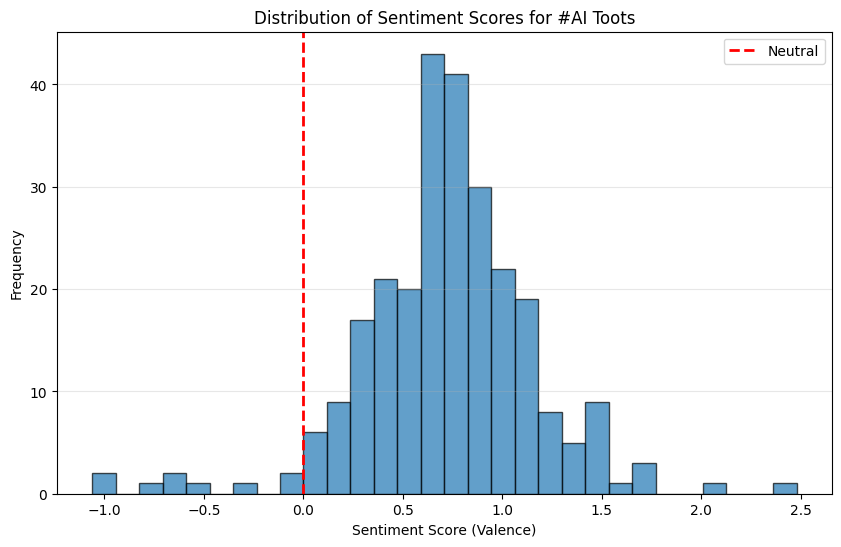

In [14]:
import matplotlib.pyplot as plt

# Create histogram of sentiment scores
plt.figure(figsize=(10, 6))
plt.hist(df_toots['sentiment_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
plt.xlabel('Sentiment Score (Valence)')
plt.ylabel('Frequency')
plt.title('Distribution of Sentiment Scores for #AI Toots')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Let's analyze how sentiment varies across time by computing the average sentiment score per hour:

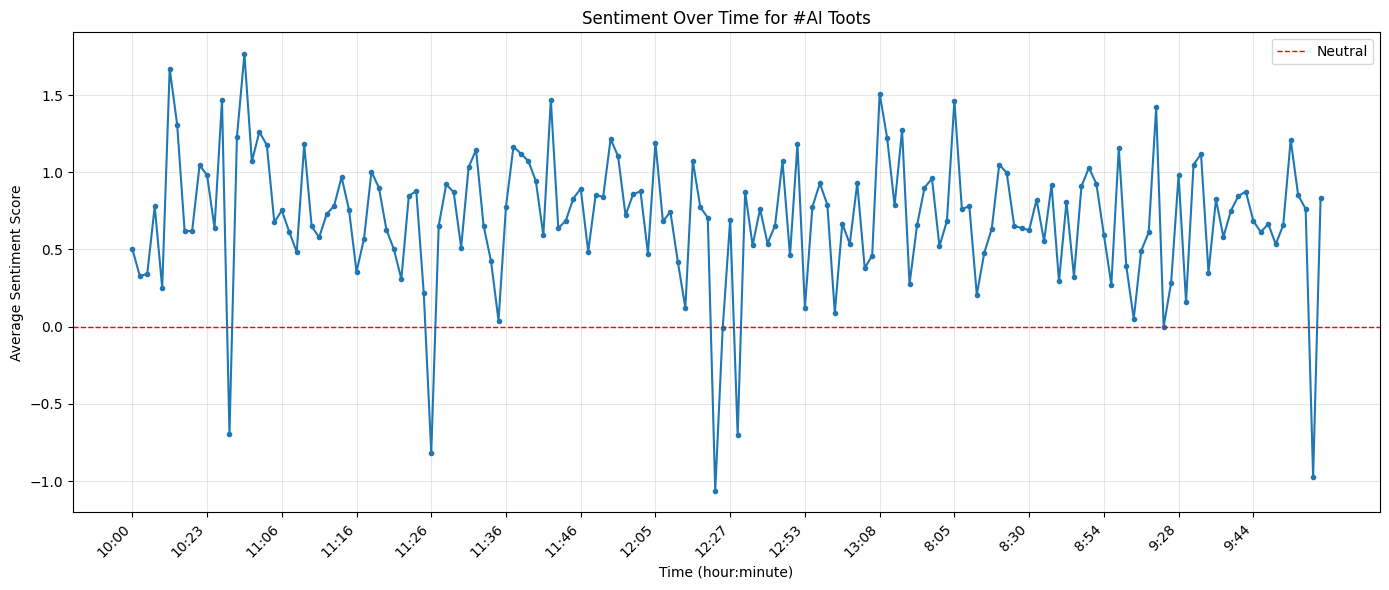

Time range: 10:00 to 9:58


In [15]:
# Extract hour and minute from created_at timestamps
df_toots['hour'] = df_toots['created_at'].dt.hour
df_toots['minute'] = df_toots['created_at'].dt.minute
df_toots['hour_minute'] = df_toots['hour'].astype(str) + ':' + df_toots['minute'].astype(str).str.zfill(2)

# Compute average sentiment per hour:minute
sentiment_by_time = df_toots.groupby('hour_minute')['sentiment_score'].mean().reset_index()
sentiment_by_time.columns = ['hour_minute', 'avg_sentiment']

# Plot sentiment over time
plt.figure(figsize=(14, 6))
plt.plot(range(len(sentiment_by_time)), sentiment_by_time['avg_sentiment'], marker='o', markersize=3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Neutral')
plt.xlabel('Time (hour:minute)')
plt.ylabel('Average Sentiment Score')
plt.title('Sentiment Over Time for #AI Toots')
plt.xticks(range(0, len(sentiment_by_time), max(1, len(sentiment_by_time)//15)), 
           sentiment_by_time['hour_minute'][::max(1, len(sentiment_by_time)//15)], 
           rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Time range: {sentiment_by_time['hour_minute'].iloc[0]} to {sentiment_by_time['hour_minute'].iloc[-1]}")

#### Examining Most Negative Toots

Let's inspect the most negative toots to understand what content receives the lowest sentiment scores:

In [16]:
# Sort by sentiment score and display the most negative toots
most_negative = df_toots.nsmallest(3, 'sentiment_score')[['text', 'sentiment_score', 'created_at']]

print("Top 3 most negative toots:\n")
for idx, row in most_negative.iterrows():
    print(f"Score: {row['sentiment_score']:.3f} | Time: {row['created_at']}")
    print(f"Text: {row['text'][:200]}...")  # Show first 200 characters
    print("-" * 80)

Top 3 most negative toots:

Score: -1.062 | Time: 2026-02-12 12:19:38.046000+00:00
Text: The irony of #Google worrying about #intellectualproperty theft should not be lost on anyone. https://www.nbcnews.com/tech/security/google-gemini-hit-100000-prompts-cloning-attempt-rcna258657#ai...
--------------------------------------------------------------------------------
Score: -0.974 | Time: 2026-02-12 09:56:31+00:00
Text: @dw_innovation @reutersinstitute the main problem is that "#AI" is a net negative and gross negative as it's useage and setups are intrinsically designed to sow distrust and generate disinformation....
--------------------------------------------------------------------------------
Score: -0.816 | Time: 2026-02-12 11:26:25.243000+00:00
Text: 📰 Death Penalty Dropped in Luigi Mangione Case, Life Sentence Risk RemainsA U.S. federal judge has dismissed federal firearms charges against Luigi Mangione, who is accused of murdering UnitedHealthca...
------------------------------

### VADER

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is a lexicon and rule-based sentiment analysis tool specifically designed for social media and online text. Unlike simple lexicon-based approaches, VADER incorporates sophisticated rules that capture how sentiment is expressed in social media posts.

#### Key Features

1. **Negators and amplifiers**: Words like "not", "never", "extremely" modify the sentiment of nearby words
2. **Punctuation Sensitivity**: Exclamation marks (!) boost sentiment intensity
3. **Capitalization**: ALL CAPS increases sentiment intensity
4. **Degree Modifiers**: Words like "very", "kind of", "extremely" adjust sentiment strength
5. **Emoticons and Emoji**: Recognizes :) :( and their sentiment
6. **Adversative Conjunctions**: Handles "but" which shifts emphasis to the latter clause

#### The Compound Score

The **compound score** is VADER's primary metric, normalized between -1 (most negative) and +1 (most positive). 

**How it works:**
- Sums all adjusted valence scores (after applying negation, intensifiers, punctuation, etc.)
- Applies a special normalization that accounts for text length and intensity
- Unlike simple averaging, it ensures longer texts don't automatically get more extreme scores

**Standard classification thresholds:**
- **Positive**: compound ≥ 0.05
- **Neutral**: -0.05 < compound < 0.05  
- **Negative**: compound ≤ -0.05

**Additional scores:** VADER also provides `pos`, `neu`, and `neg` which are the proportions of text that fall into each category (sum to 1.0). All scores are returned by the `polarity_scores()` method:

```python
scores = vader.polarity_scores("AI is amazing!")
# Returns: {'neg': 0.0, 'neu': 0.294, 'pos': 0.706, 'compound': 0.6588}
```

#### Demonstrating VADER's Valence Shifters

Let's see how VADER handles various linguistic features that a simple lexicon-based approach would miss:

In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER analyzer
vader = SentimentIntensityAnalyzer()

# Example sentences demonstrating valence shifters
examples = [
    # Negation
    "AI is good",
    "AI is not good",
    "AI is not bad",
    
    # Intensifiers
    "AI is good",
    "AI is very good",
    "AI is extremely good",
    
    # Punctuation
    "AI is amazing",
    "AI is amazing!",
    "AI is amazing!!!",
    
    # Capitalization
    "AI is great",
    "AI is GREAT",
    
    # Contrastive conjunction (but)
    "I like AI but I hate the hype",
    "I hate the hype but I like AI",
    
    # Emoticons
    "AI is interesting :)",
    "AI is interesting :(",

    # Emojis (if supported by VADER)
    "AI is interesting 😊",
    "AI is interesting 😞"
]

print("VADER Valence Shifter Examples:\n")
for text in examples:
    scores = vader.polarity_scores(text)
    print(f"Text: {text:45} | Compound: {scores['compound']:+.3f}")

VADER Valence Shifter Examples:

Text: AI is good                                    | Compound: +0.440
Text: AI is not good                                | Compound: -0.341
Text: AI is not bad                                 | Compound: +0.431
Text: AI is good                                    | Compound: +0.440
Text: AI is very good                               | Compound: +0.493
Text: AI is extremely good                          | Compound: +0.493
Text: AI is amazing                                 | Compound: +0.586
Text: AI is amazing!                                | Compound: +0.624
Text: AI is amazing!!!                              | Compound: +0.688
Text: AI is great                                   | Compound: +0.625
Text: AI is GREAT                                   | Compound: +0.703
Text: I like AI but I hate the hype                 | Compound: -0.649
Text: I hate the hype but I like AI                 | Compound: +0.226
Text: AI is interesting :)                  

**Key Observations:**

- **Negation reverses sentiment**: "good" → "not good" flips from positive to negative
- **Intensifiers amplify**: "very" and "extremely" boost the magnitude
- **Punctuation adds emphasis**: More exclamation marks increase intensity
- **Capitalization signals shouting**: ALL CAPS strengthens sentiment
- **"But" shifts focus**: The clause after "but" receives more weight
- **Emoticons contribute**: :) and :( add their own sentiment signals

These sophisticated rules make VADER much more effective for social media text than simple word-matching approaches.

#### Applying VADER to Our Toots

Now let's apply VADER to our Mastodon data and compare with our manual approach:

In [18]:
# Apply VADER to all toots
df_toots['vader_compound'] = df_toots['text'].apply(lambda x: vader.polarity_scores(x)['compound'])
df_toots['vader_pos'] = df_toots['text'].apply(lambda x: vader.polarity_scores(x)['pos'])
df_toots['vader_neu'] = df_toots['text'].apply(lambda x: vader.polarity_scores(x)['neu'])
df_toots['vader_neg'] = df_toots['text'].apply(lambda x: vader.polarity_scores(x)['neg'])

# Compare statistics
print("Average VADER and Manual Lexicon Scores :\n")
print(df_toots[['sentiment_score', 'vader_compound']].mean())

print(f"\n\nVADER Sentiment Statistics:")
print(df_toots['vader_compound'].describe())


Average VADER and Manual Lexicon Scores :

sentiment_score    0.723271
vader_compound     0.279098
dtype: float64


VADER Sentiment Statistics:
count    265.000000
mean       0.279098
std        0.491295
min       -0.993200
25%        0.000000
50%        0.381800
75%        0.670500
max        0.954000
Name: vader_compound, dtype: float64


In [19]:
# Compare manual vs VADER scores
print("Comparison of Manual Lexicon vs VADER:\n")
df_toots[['text', 'sentiment_score', 'vader_compound']].head(10)

Comparison of Manual Lexicon vs VADER:



,text,sentiment_score,vader_compound
0,I just set up #pai on a fresh installation of ...,0.681875,0.0342
1,Every AI creator is pushing VPS setups for Ope...,0.686471,0.2263
2,Introducing Sagents -- an open-source #ElixirL...,0.521000,0.0000
3,Looking to upgrade your career with an MBA? Di...,0.960000,0.6958
4,The AI experiment that shocked researchersEncr...,0.899333,0.4019
5,I want to see Peter Theil and Paul Kingsnorth ...,0.655693,-0.9661
6,So a maintainer on GitHub declines a PR from a...,0.276154,-0.3400
7,I don’t want #AI to do my job so I can cook my...,1.271667,0.1531
8,"Synthesia, the UK AI avatars startup, raised 0...",0.378750,0.2732
9,Explore AI tools that can support teachers in ...,1.191111,0.6908


#### Visualizing VADER Results

Let's compare the distribution of VADER scores with our manual approach:

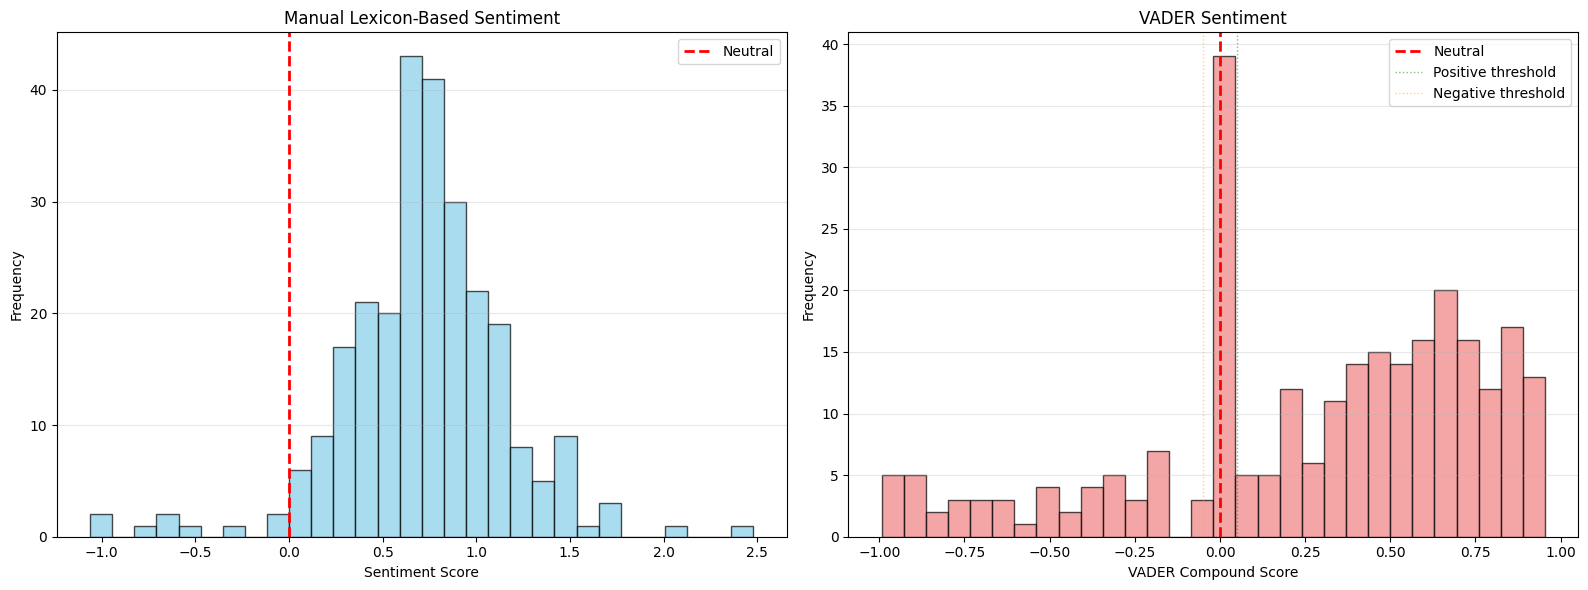


Correlation between Manual and VADER scores: 0.464


In [20]:
# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Manual lexicon distribution
axes[0].hist(df_toots['sentiment_score'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Manual Lexicon-Based Sentiment')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# VADER distribution
axes[1].hist(df_toots['vader_compound'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[1].axvline(x=0.05, color='green', linestyle=':', linewidth=1, alpha=0.5, label='Positive threshold')
axes[1].axvline(x=-0.05, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='Negative threshold')
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('VADER Sentiment')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation between methods
correlation = df_toots['sentiment_score'].corr(df_toots['vader_compound'])
print(f"\nCorrelation between Manual and VADER scores: {correlation:.3f}")

### TextBlob

`TextBlob` is another popular sentiment analysis library that provides a simpler, more general-purpose approach compared to VADER. Moreover, next so sentiment it also includes subjectivity. To perform the analysis, there are **two analyzers** available: 

1. **PatternAnalyzer (default)**: Lexicon-based approach using the `Pattern` library's sentiment dictionary
2. **NaiveBayesAnalyzer**: Machine learning classifier trained on movie reviews (supervised learning)

#### Key Differences from VADER

- **Scope**: Designed for general text, not specifically optimized for social media
- **Output**: Returns two scores:
  - **Polarity**: -1 (negative) to +1 (positive) (`PatternAnalyzer`) or pos or neg labels (`NaiveBayesAnalyzer`)
  - **Subjectivity**: 0 (objective) to 1 (subjective)
- **Rule handling**: Less sophisticated than VADER (doesn't strongly emphasize punctuation, caps, or "but" clauses), however the main (de-)amplifiers are present. 

#### Using TextBlob

```python
from textblob import TextBlob
# Default: PatternAnalyzer (lexicon-based)
blob = TextBlob("AI is amazing!")
print(blob.sentiment)
# Returns: Sentiment(polarity=0.6, subjectivity=1.0)
```

#### Comparing TextBlob with VADER

Let's see how `TextBlob` handles the same examples we tested with `VADER`. We'll compare both the default `PatternAnalyzer` (lexicon-based) and the `NaiveBayesAnalyzer` (ML-based):

In [21]:
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer

# Ensure the movie_reviews corpus is downloaded for NaiveBayesAnalyzer
nltk.download('movie_reviews')

# Test the same examples with both TextBlob analyzers
print("Comparing VADER vs TextBlob (Pattern) vs TextBlob (NaiveBayes):\n")
print(f"{'Text':<45} | {'VADER':>8} | {'TB-Pattern':>11} | {'TB-NB':>6}")
print("=" * 80)

for text in examples:  # Use all examples
    vader_score = vader.polarity_scores(text)['compound']
    textblob_pattern = TextBlob(text).sentiment.polarity
    textblob_nb = TextBlob(text, analyzer=NaiveBayesAnalyzer()).sentiment.classification
    
    # NaiveBayesAnalyzer returns 'pos' or 'neg', convert to simple display
    nb_label = textblob_nb
    print(f"{text:<45} | {vader_score:>+8.3f} | {textblob_pattern:>+11.3f} | {nb_label:>6}")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/matthiasbogaert/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


Comparing VADER vs TextBlob (Pattern) vs TextBlob (NaiveBayes):

Text                                          |    VADER |  TB-Pattern |  TB-NB
AI is good                                    |   +0.440 |      +0.700 |    pos
AI is not good                                |   -0.341 |      -0.350 |    pos
AI is not bad                                 |   +0.431 |      +0.350 |    neg
AI is good                                    |   +0.440 |      +0.700 |    pos
AI is very good                               |   +0.493 |      +0.910 |    pos
AI is extremely good                          |   +0.493 |      +0.700 |    pos
AI is amazing                                 |   +0.586 |      +0.600 |    pos
AI is amazing!                                |   +0.624 |      +0.750 |    pos
AI is amazing!!!                              |   +0.688 |      +1.000 |    pos
AI is great                                   |   +0.625 |      +0.800 |    pos
AI is GREAT                                   |   +0.70

**Key Observations:**

- `PatternAnalyzer` (default): Lexicon-based, but simpler than VADER
  - Less sensitive to negation than VADER
  - Smaller lexicon for amplifiers (e.g., "extremely" is not recognized)
  - Only one intensifier is taken into account
  - Treats both clauses in "but" sentences equally
  - **Smaller lexicon**: Many technical or domain-specific terms (like "AI", "algorithms") return 0.0 because they're not in TextBlob's sentiment dictionary
  
- `NaiveBayesAnalyzer`: ML classifier trained on movie reviews
  - Returns binary classification (pos/neg) rather than continuous score
  - Can struggle with social media text since it was trained on formal movie reviews
  - May not capture nuances that lexicon-based approaches detect

**For social media text**, VADER typically performs best due to its rule-based social media optimizations, larger lexicon, and better handling of informal/technical content.

#### Applying TextBlob to Our Toots

We'll use the default `PatternAnalyzer` for our dataset since it provides continuous scores (like VADER) rather than binary classifications. Besides sentiment, let's also gather subjectivity. 

In [22]:
# Apply TextBlob to all toots
df_toots['textblob_polarity'] = df_toots['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_toots['textblob_subjectivity'] = df_toots['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Compare statistics
print("\n\nAverage scores across all methods:")
print(df_toots[['sentiment_score', 'vader_compound', 'textblob_polarity']].mean())



Average scores across all methods:
sentiment_score      0.723271
vader_compound       0.279098
textblob_polarity    0.090096
dtype: float64


In [23]:
# Compare all three methods
print("Comparing all three sentiment methods:\n")
df_toots[['text', 'sentiment_score', 'vader_compound', 'textblob_polarity']].head(10)


Comparing all three sentiment methods:



,text,sentiment_score,vader_compound,textblob_polarity
0,I just set up #pai on a fresh installation of ...,0.681875,0.0342,0.433333
1,Every AI creator is pushing VPS setups for Ope...,0.686471,0.2263,0.047619
2,Introducing Sagents -- an open-source #ElixirL...,0.521000,0.0000,0.175000
3,Looking to upgrade your career with an MBA? Di...,0.960000,0.6958,0.000000
4,The AI experiment that shocked researchersEncr...,0.899333,0.4019,0.038889
5,I want to see Peter Theil and Paul Kingsnorth ...,0.655693,-0.9661,0.007363
6,So a maintainer on GitHub declines a PR from a...,0.276154,-0.3400,0.000000
7,I don’t want #AI to do my job so I can cook my...,1.271667,0.1531,0.000000
8,"Synthesia, the UK AI avatars startup, raised 0...",0.378750,0.2732,0.053333
9,Explore AI tools that can support teachers in ...,1.191111,0.6908,0.350000


**Key Observations:**

- Notice that **TextBlob produces more zero scores** than VADER or the manual lexicon. 
    - This is because TextBlob's `PatternAnalyzer` uses a smaller, more conservative sentiment dictionary that doesn't recognize many technical or domain-specific terms (e.g., "AI", "algorithms", "machine learning"). 
    - Neutral reporting (e.g., news headlines, technical descriptions) are also not considered as having sentiment. 
    - When text contains primarily these unrecognized terms, `TextBlob` returns 0.0, whereas VADER's larger lexicon and contextual rules can still detect sentiment.
- `VADER` and the manual lexicon often find sentiment in the same toots because they have broader coverage. However, the manual approach is too positive given that it cannot handle negation.  

Let's also have a look at subjectivity:

In [24]:
# Examine subjectivity scores
print("Subjectivity statistics:")
print(df_toots['textblob_subjectivity'].describe())

Subjectivity statistics:
count    265.000000
mean       0.447851
std        0.244027
min        0.000000
25%        0.300758
50%        0.450000
75%        0.600000
max        1.000000
Name: textblob_subjectivity, dtype: float64


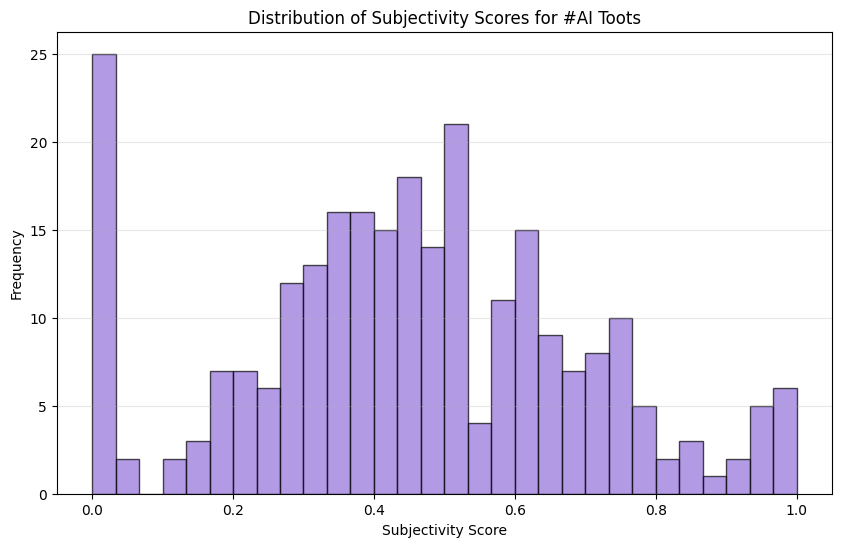

In [25]:
# Create histogram of subjectivity scores
plt.figure(figsize=(10, 6))
plt.hist(df_toots['textblob_subjectivity'], bins=30, edgecolor='black', alpha=0.7, color='mediumpurple')
plt.xlabel('Subjectivity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Subjectivity Scores for #AI Toots')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [26]:
# Show examples of most objective and most subjective toots
print("\nMost objective toots (subjectivity close to 0):")
most_objective = df_toots.nsmallest(3, 'textblob_subjectivity')[['text', 'textblob_polarity', 'textblob_subjectivity']]
for idx, row in most_objective.iterrows():
    print(f"\nSubjectivity: {row['textblob_subjectivity']:.3f} | Polarity: {row['textblob_polarity']:.3f}")
    print(f"Text: {row['text'][:150]}...")

print("\n" + "="*80)
print("\nMost subjective toots (subjectivity close to 1):")
most_subjective = df_toots.nlargest(3, 'textblob_subjectivity')[['text', 'textblob_polarity', 'textblob_subjectivity']]
for idx, row in most_subjective.iterrows():
    print(f"\nSubjectivity: {row['textblob_subjectivity']:.3f} | Polarity: {row['textblob_polarity']:.3f}")
    print(f"Text: {row['text'][:150]}...")


Most objective toots (subjectivity close to 0):

Subjectivity: 0.000 | Polarity: 0.000
Text: Looking to upgrade your career with an MBA? Dive into data-driven & AI-powered business models with Steinbeis University's MBA in Management Excellenc...

Subjectivity: 0.000 | Polarity: 0.000
Text: I don’t want #AI to do my job so I can cook my meal. I want AI to cook my meal so I can do my job....

Subjectivity: 0.000 | Polarity: 0.000
Text: »This $7,999 robot will fold (some of) your laundry« https://www.theverge.com/tech/877851/weave-isaac-robot-fold-laundry?AIagent.at #AIagent #AI #ML #...


Most subjective toots (subjectivity close to 1):

Subjectivity: 1.000 | Polarity: -0.300
Text: 📰 SpaceX Applies to Launch One Million Satellites Into Orbit for AI Processing NeedsElon Musk's SpaceX has filed an official application to launch one...

Subjectivity: 1.000 | Polarity: -0.600
Text: 📰 Tesla Halts Model S and Model X Production: Shifts Focus to Robotics and Artificial IntelligenceTesla has d

### Visualizing All Three Sentiment Methods

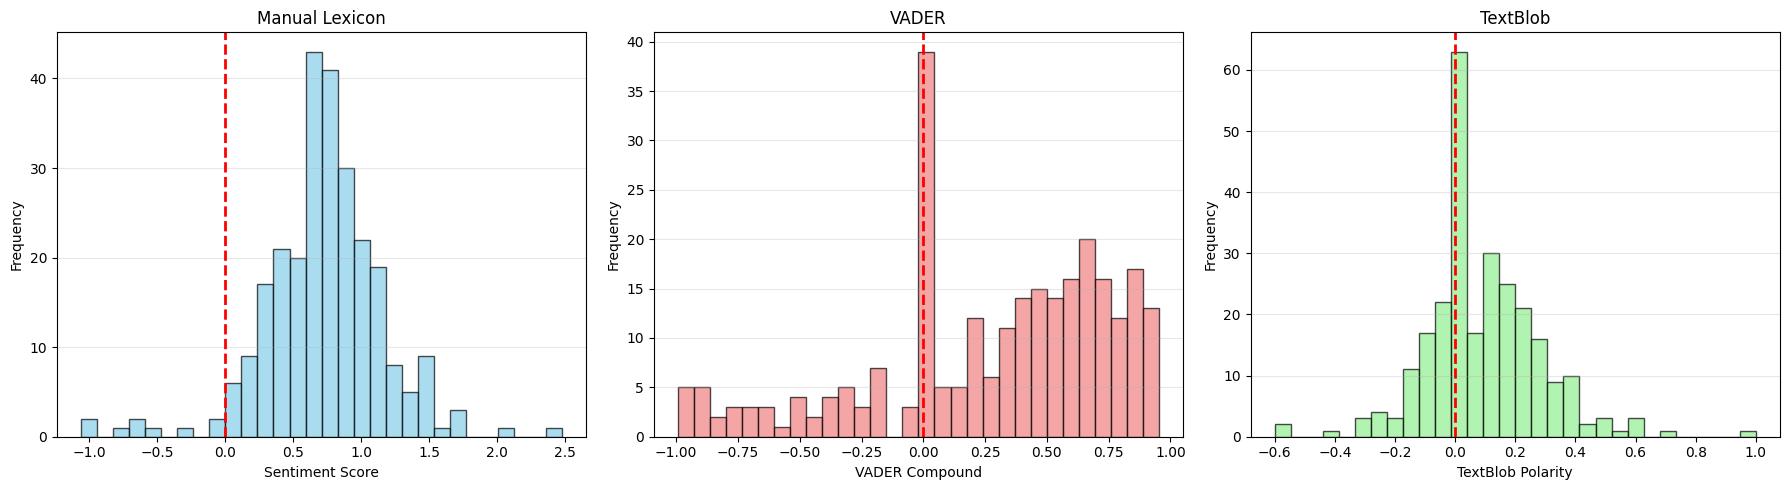


Correlation between methods:
                   sentiment_score  vader_compound  textblob_polarity
sentiment_score           1.000000        0.463920           0.296322
vader_compound            0.463920        1.000000           0.175855
textblob_polarity         0.296322        0.175855           1.000000


In [27]:
# Create three-way comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Manual lexicon
axes[0].hist(df_toots['sentiment_score'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Manual Lexicon')
axes[0].grid(axis='y', alpha=0.3)

# VADER
axes[1].hist(df_toots['vader_compound'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('VADER Compound')
axes[1].set_ylabel('Frequency')
axes[1].set_title('VADER')
axes[1].grid(axis='y', alpha=0.3)

# TextBlob
axes[2].hist(df_toots['textblob_polarity'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('TextBlob Polarity')
axes[2].set_ylabel('Frequency')
axes[2].set_title('TextBlob')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation matrix
print("\nCorrelation between methods:")
correlation_matrix = df_toots[['sentiment_score', 'vader_compound', 'textblob_polarity']].corr()
print(correlation_matrix)

### NRCLex: Emotion Detection

Beyond sentiment (positive/negative), we can also detect specific **emotions** using the **NRC Emotion Lexicon**. This lexicon associates words with eight basic emotions based on Plutchik's wheel of emotions:

1. **Joy** - happiness, pleasure, contentment
2. **Trust** - faith, acceptance, confidence
3. **Fear** - anxiety, apprehension, worry
4. **Surprise** - astonishment, amazement
5. **Sadness** - sorrow, grief, depression
6. **Disgust** - revulsion, loathing, aversion
7. **Anger** - rage, irritation, annoyance
8. **Anticipation** - expectation, interest, vigilance

**Why emotion detection matters:**
- Emotions provide richer psychological insights than binary sentiment
- Different emotions can have the same sentiment valence (fear and sadness are both negative but the impact is totally different)
- Useful for understanding deeper emotional responses (e.g., well-being)

**How NRCLex scores work:**
- It returns **affect frequencies**: the proportion of words in the text that match each emotion category
- Scores range from **0 to 1** (0% to 100%)
- Scores are normalized: calculated as (emotion word count) / (total emotion words)
    - A score of 0.15 for "joy" means 15% of emotion-bearing words in the text express joy
- Multiple emotions can be present in the same text (emotions are not mutually exclusive)

Let's apply `nrcLex` to our toots to see what emotions are expressed about #AI.


In [28]:
from nrclex import NRCLex

def analyze_emotions_nrclex(text):
    """
    Analyze emotions in text using NRCLex.
    Returns a dictionary with emotion scores and sentiment.
    """
    emotion = NRCLex(text)
    
    # Get emotion frequencies (raw counts)
    emotions = emotion.raw_emotion_scores
    
    # Get affect frequencies (normalized proportions)
    affect = emotion.affect_frequencies
    
    return {
        'fear': affect.get('fear', 0),
        'anger': affect.get('anger', 0),
        'anticipation': affect.get('anticipation', 0),
        'trust': affect.get('trust', 0),
        'surprise': affect.get('surprise', 0),
        'nrc_positive': affect.get('positive', 0),
        'nrc_negative': affect.get('negative', 0),
        'sadness': affect.get('sadness', 0),
        'disgust': affect.get('disgust', 0),
        'joy': affect.get('joy', 0)
    }

# Apply NRCLex emotion analysis to all toots
print("Analyzing emotions with NRCLex...")
emotion_results = df_toots['text'].apply(analyze_emotions_nrclex)

# Convert results to DataFrame and merge with original
emotion_df = pd.DataFrame(emotion_results.tolist())

df_toots_emotions = pd.concat([df_toots, emotion_df], axis=1)

print("✓ Emotion analysis complete!")
df_toots_emotions.head()

Analyzing emotions with NRCLex...
✓ Emotion analysis complete!


,text,created_at,sentiment_score,hour,minute,hour_minute,vader_compound,vader_pos,vader_neu,vader_neg,...,fear,anger,anticipation,trust,surprise,nrc_positive,nrc_negative,sadness,disgust,joy
0,I just set up #pai on a fresh installation of ...,2026-02-12 13:34:41+00:00,0.681875,13,34,13:34,0.0342,0.081,0.857,0.063,...,0.000000,0.000000,0.000000,0.400000,0.000000,0.600000,0.000000,0.000000,0.0,0.0
1,Every AI creator is pushing VPS setups for Ope...,2026-02-12 13:34:38.285000+00:00,0.686471,13,34,13:34,0.2263,0.070,0.889,0.041,...,0.142857,0.142857,0.000000,0.285714,0.000000,0.142857,0.142857,0.142857,0.0,0.0
2,Introducing Sagents -- an open-source #ElixirL...,2026-02-12 13:31:25.666000+00:00,0.521000,13,31,13:31,0.0000,0.000,1.000,0.000,...,0.000000,0.000000,0.000000,0.250000,0.000000,0.500000,0.250000,0.000000,0.0,0.0
3,Looking to upgrade your career with an MBA? Di...,2026-02-12 13:28:12.559000+00:00,0.960000,13,28,13:28,0.6958,0.078,0.922,0.000,...,0.000000,0.000000,0.500000,0.000000,0.000000,0.500000,0.000000,0.000000,0.0,0.0
4,The AI experiment that shocked researchersEncr...,2026-02-12 13:23:20.744000+00:00,0.899333,13,23,13:23,0.4019,0.115,0.831,0.053,...,0.000000,0.000000,0.222222,0.111111,0.222222,0.222222,0.222222,0.000000,0.0,0.0


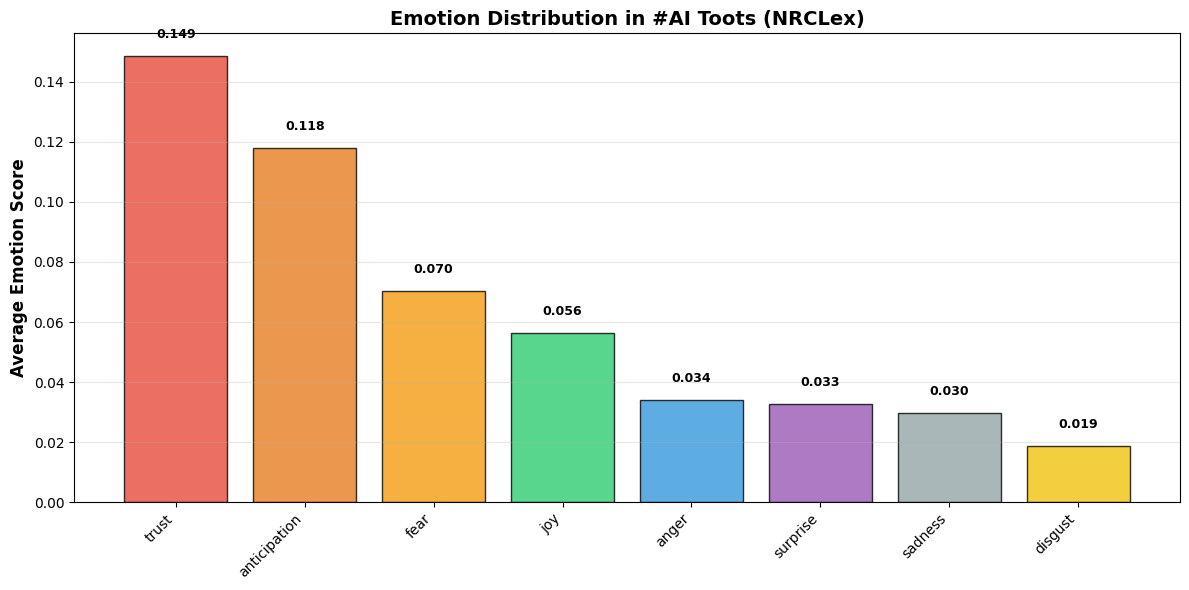

In [29]:
# Visualize emotion distribution
import matplotlib.pyplot as plt
import numpy as np

# Calculate average emotion scores across all toots
emotion_cols = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']
avg_emotions = df_toots_emotions[emotion_cols].mean().sort_values(ascending=False)

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#3498db', '#9b59b6', '#95a5a6', '#f1c40f']
bars = ax.bar(range(len(avg_emotions)), avg_emotions.values, color=colors, edgecolor='black', alpha=0.8)

ax.set_xticks(range(len(avg_emotions)))
ax.set_xticklabels(avg_emotions.index, rotation=45, ha='right')
ax.set_ylabel('Average Emotion Score', fontsize=12, fontweight='bold')
ax.set_title('Emotion Distribution in #AI Toots (NRCLex)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, avg_emotions.values)):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.005, f'{value:.3f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


**Deriving sentiment from emotions:**
- NRCLex also provides **positive** and **negative** scores alongside emotions
- A **net sentiment score** can be derived by: `positive - negative`
- This emotion-based sentiment can be compared with other lexicon-based methods (VADER, TextBlob, manual dictionary)


Correlation matrix:
                   sentiment_score  vader_compound  textblob_polarity  \
sentiment_score           1.000000        0.463920           0.296322   
vader_compound            0.463920        1.000000           0.175855   
textblob_polarity         0.296322        0.175855           1.000000   
nrclex_sentiment          0.293534        0.348186           0.195291   

                   nrclex_sentiment  
sentiment_score            0.293534  
vader_compound             0.348186  
textblob_polarity          0.195291  
nrclex_sentiment           1.000000  


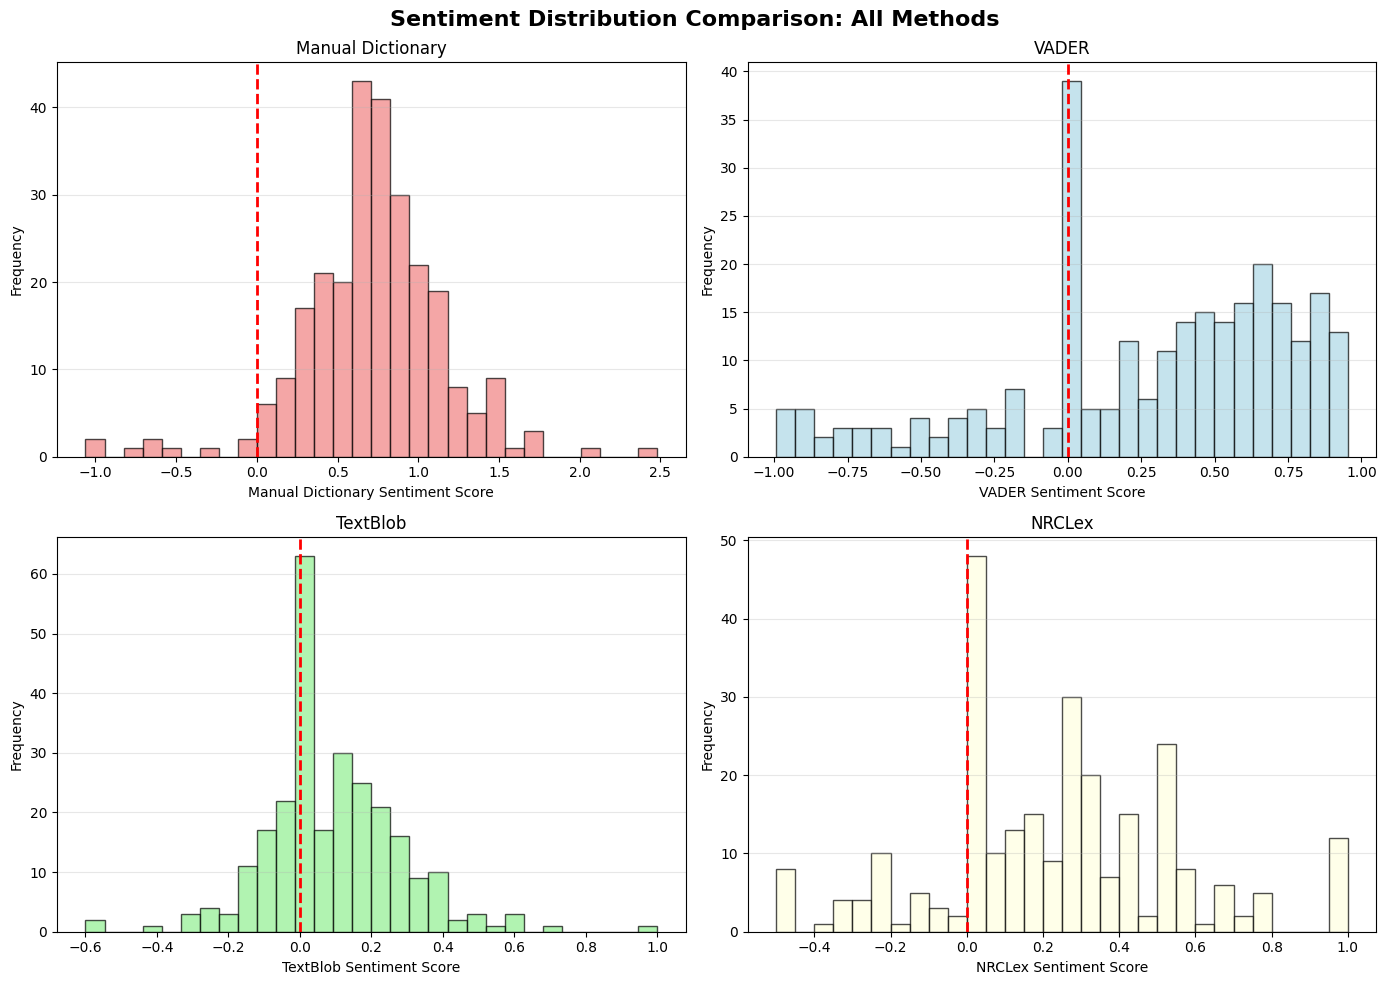

In [30]:
# Calculate NRCLex net sentiment (nrc_positive - nrc_negative)
df_toots_emotions['nrclex_sentiment'] = df_toots_emotions['nrc_positive'] - df_toots_emotions['nrc_negative']

# Correlation with other methods
sentiment_methods = ['sentiment_score', 'vader_compound', 'textblob_polarity', 'nrclex_sentiment']
correlation_matrix = df_toots_emotions[sentiment_methods].corr()

print("\nCorrelation matrix:")
print(correlation_matrix)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = [
    ('sentiment_score', 'Manual Dictionary', 0),
    ('vader_compound', 'VADER', 1),
    ('textblob_polarity', 'TextBlob', 2),
    ('nrclex_sentiment', 'NRCLex', 3)
]

for method_col, method_name, idx in methods:
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_toots_emotions[method_col], bins=30, edgecolor='black', alpha=0.7, 
            color=['lightcoral', 'lightblue', 'lightgreen', 'lightyellow'][idx])
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel(f'{method_name} Sentiment Score')
    ax.set_ylabel('Frequency')
    ax.set_title(method_name)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Sentiment Distribution Comparison: All Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Machine Learning Approach

### Traditional Lexical Features



#### Loading the Dataset

To showcase how to implement a traditional machine learning approach, we'll use a pre-labeled dataset of comments where human annotators have classified each text as positive (+1) or negative (-1). The dataset was scraped from the Facebook page of non-profit organization. 

In [43]:
# Load the labeled sentiment dataset
sentiment_df = pd.read_csv("./Data/SentimentReal.csv", encoding='latin1')

print(f"Dataset shape: {sentiment_df.shape}")
print(f"\nLabel distribution:")
print(sentiment_df['label'].value_counts())
print(f"\nFirst few examples:")
sentiment_df.head()

Dataset shape: (95, 2)

Label distribution:
label
-1    55
 1    40
Name: count, dtype: int64

First few examples:


,message,label
0,Well your chief executive should go. I wont be...,-1
1,really desperate now its 7 years on and this a...,-1
2,I believe,1
3,So unbelievably sad that the enormous amount o...,-1
4,Am from Kenya I would like to be a volunteer.,1


The labels are coded as -1 and +1. Let's recode this to the default 0 (negative) and 1 (positive). 

In [44]:
# Convert labels from -1/+1 to 0/1
sentiment_df['label_binary'] = sentiment_df['label'].map({-1: 0, 1: 1})
sentiment_df.drop(columns=['label'], inplace=True)
sentiment_df.head()

,message,label_binary
0,Well your chief executive should go. I wont be...,0
1,really desperate now its 7 years on and this a...,0
2,I believe,1
3,So unbelievably sad that the enormous amount o...,0
4,Am from Kenya I would like to be a volunteer.,1


#### Train-Test Split

We split the data into training (60%) and test (40%) sets. Remember, the training set is used to learn the underlying patterns and parameters, while the test set evaluates how well our model performs on unseen data.

Following best practice, we are using a stratified train/test split to make sure that the label distribution is the same in the train and test set. 

In [45]:
from sklearn.model_selection import train_test_split

# Split data: 60% train, 40% test
X_train, X_test, y_train, y_test = train_test_split(
    sentiment_df['message'],
    sentiment_df['label_binary'],
    test_size=0.4,
    random_state=1000,
    stratify=sentiment_df['label_binary']  # Maintain label distribution
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set label distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set label distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 57
Test set size: 38

Training set label distribution:
label_binary
0    0.578947
1    0.421053
Name: proportion, dtype: float64

Test set label distribution:
label_binary
0    0.578947
1    0.421053
Name: proportion, dtype: float64


#### Model 1: TF-IDF + Logistic Regression

We will begin with the most straightforward and popular lexical features: **TF-IDF (Term Frequency-Inverse Document Frequency)**. TF-IDF represents text by weighting terms based on:
- **Term Frequency (TF)**: How often a word appears in a document
- **Inverse Document Frequency (IDF)**: How unique/rare a word is across all documents

This helps identify discriminative terms: common words like "the" get low weights, while distinctive sentiment words get high weights.

`sklearn's TfidfVectorizer` combines several text preprocessing steps:
- **Tokenization**: Splits text into words
- **Lowercasing**: Converts all text to lowercase for consistency

- **Stop word removal**: Filters out common words ("the", "a", "is") that don't carry sentiment

- **TF-IDF weighting**: Applies the TF-IDF formula to each term

- **Vocabulary building**: Creates a mapping from words to feature indices

**Key parameters** we'll use:

- `max_features`: Limits vocabulary to most frequent N terms (reduces dimensionality)

- `ngram_range`: Specifies word sequences to consider (e.g., (1,1) = unigrams only, (1,2) = unigrams + bigrams)

- `lowercase`: Normalizes text case
- `stop_words='english'`: Removes common English words

**Note:** The TF-IDF features are learned from training data only (avoiding data leakage) and the `Pipeline` will automatically apply the same procedure to the test set. 

Let's implement a TF-IDF approach with **logistic regression** and evaluate performance using the AUC.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# Create TF-IDF + Logistic Regression pipeline
pipeline_tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50,       # Limit to top 100 terms (can be tuned: try 100, 500, 1000)
        ngram_range=(1, 1),     # Use unigrams only (can experiment with (1,2) for bigrams)
        lowercase=True,
        strip_accents='unicode',
        stop_words='english'
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=1000
    ))
])

# Note: These hyperparameters can be further tuned using GridSearchCV or RandomizedSearchCV

# Train the model
pipeline_tfidf_lr.fit(X_train, y_train)

# Make predictions (probabilities for positive class)
y_pred_prob_tfidf_lr = pipeline_tfidf_lr.predict_proba(X_test)[:, 1]
y_pred_tfidf_lr = pipeline_tfidf_lr.predict(X_test)

# Calculate AUC

auc_tfidf_lr = roc_auc_score(y_test, y_pred_prob_tfidf_lr)
print(f"TF-IDF + Logistic Regression AUC: {auc_tfidf_lr:.4f}")

TF-IDF + Logistic Regression AUC: 0.6875


#### Model 2: TF-IDF + Random Forest

Let's also try out **Random Forest**, an ensemble method that builds multiple decision trees and combines their predictions.  The model is known to be prone to overfitting which can be particularty useful when introduced with a large number of lexical features. 

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Create TF-IDF + Random Forest pipeline
pipeline_tfidf_rf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50,
        ngram_range=(1, 1),
        lowercase=True,
        strip_accents='unicode',
        stop_words='english'
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=1000,
        n_jobs=-1  # Use all available cores
    ))
])

# Train the model
pipeline_tfidf_rf.fit(X_train, y_train)

# Make predictions
y_pred_prob_tfidf_rf = pipeline_tfidf_rf.predict_proba(X_test)[:, 1]
y_pred_tfidf_rf = pipeline_tfidf_rf.predict(X_test)

# Calculate AUC
auc_tfidf_rf = roc_auc_score(y_test, y_pred_prob_tfidf_rf)
print(f"TF-IDF + Random Forest AUC: {auc_tfidf_rf:.4f}")

TF-IDF + Random Forest AUC: 0.6790


#### Model 3: LSA (SVD) + Logistic Regression

In the above example, we limited the number of featues to 100 to keep the computational complexity but also to decrease the chances of overfitting. However, this  process might make sure that several interesting words and patterns are filtered out. 

A better strategy is therefore to include as much TF-IDF terms as possible and reduce the dimensionality with 
**Latent Semantic Analysis (LSA)**. LSA uses Singular Value Decomposition (SVD) to reduce the high-dimensional TF-IDF matrix to a lower-dimensional semantic space. This:
- Captures latent semantic patterns and word relationships
- Reduces noise and sparsity
- Groups synonyms and related terms

We'll use `TruncatedSVD` (optimized for sparse matrices) with 50 components to create compact semantic representations. Again, everything is combined within a `Pipeline` to avoid data leakage. 

In [48]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# Create LSA + Logistic Regression pipeline
pipeline_lsa_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=500, # you can also put it to None to use all features
        ngram_range=(1, 1),
        lowercase=True,
        strip_accents='unicode',
        stop_words='english'
    )),
    ('svd', TruncatedSVD(
        n_components=50,       # Reduce to 20 latent dimensions
        random_state=1000
    )),
    ('normalizer', Normalizer(copy=False)),  # L2 normalization: important for distance-based classifiers like Logistic Regression
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=1000
    ))
])

# Train the model
pipeline_lsa_lr.fit(X_train, y_train)

# Make predictions
y_pred_prob_lsa_lr = pipeline_lsa_lr.predict_proba(X_test)[:, 1]
y_pred_lsa_lr = pipeline_lsa_lr.predict(X_test)

# Calculate AUC
auc_lsa_lr = roc_auc_score(y_test, y_pred_prob_lsa_lr)
print(f"LSA + Logistic Regression AUC: {auc_lsa_lr:.4f}")

# Check explained variance by SVD
svd_component = pipeline_lsa_lr.named_steps['svd']
print(f"\nVariance explained by 20 components: {svd_component.explained_variance_ratio_.sum():.4f}")

LSA + Logistic Regression AUC: 0.7685

Variance explained by 20 components: 0.9487


#### Model 4: LSA (SVD) + Random Forest

Let's apply the same procedure to random forest. 

In [49]:
# Create LSA + Random Forest pipeline
pipeline_lsa_rf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=500,
        ngram_range=(1, 1),
        lowercase=True,
        strip_accents='unicode',
        stop_words='english'
    )),
    ('svd', TruncatedSVD(
        n_components=50,
        random_state=1000
    )),
    ('normalizer', Normalizer(copy=False)),  # Not strictly needed for RF, but maintains consistency with LR pipeline
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=1000,
        n_jobs=-1
    ))
])

# Train the model
pipeline_lsa_rf.fit(X_train, y_train)

# Make predictions
y_pred_prob_lsa_rf = pipeline_lsa_rf.predict_proba(X_test)[:, 1]
y_pred_lsa_rf = pipeline_lsa_rf.predict(X_test)

# Calculate AUC
auc_lsa_rf = roc_auc_score(y_test, y_pred_prob_lsa_rf)
print(f"LSA + Random Forest AUC: {auc_lsa_rf:.4f}")

LSA + Random Forest AUC: 0.7514


#### Comparing Model Performance

In order to compare the performance of both classifiers more in detail, we will also take a look at the ROC curve, and the most common metrics from the confusion matrix. 

The **ROC (Receiver Operating Characteristic) curve** plots the true positive rate (sensitivity) against the false positive rate at various classification thresholds. The **AUC (Area Under the Curve)** summarizes overall performance:
- AUC = 1.0: Perfect classifier
- AUC = 0.5: Random classifier
- Higher AUC = Better discrimination between classes

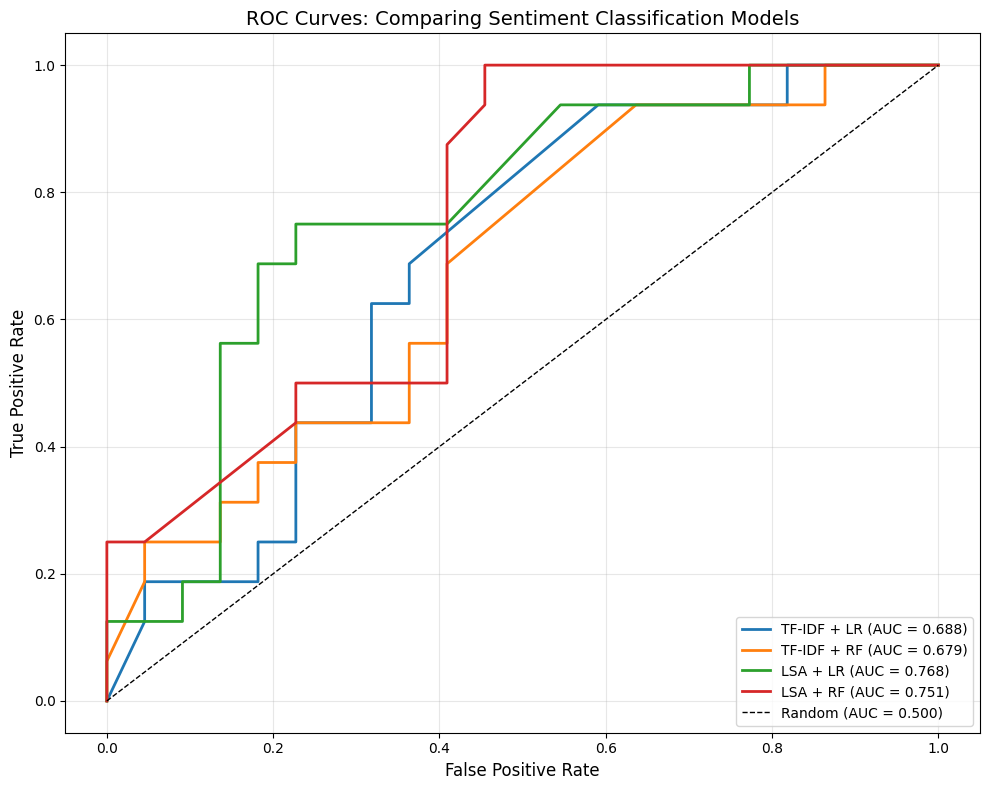

In [ ]:
# Calculate ROC curves for all models
fpr_tfidf_lr, tpr_tfidf_lr, _ = roc_curve(y_test, y_pred_prob_tfidf_lr)
fpr_tfidf_rf, tpr_tfidf_rf, _ = roc_curve(y_test, y_pred_prob_tfidf_rf)
fpr_lsa_lr, tpr_lsa_lr, _ = roc_curve(y_test, y_pred_prob_lsa_lr)
fpr_lsa_rf, tpr_lsa_rf, _ = roc_curve(y_test, y_pred_prob_lsa_rf)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_tfidf_lr, tpr_tfidf_lr, label=f'TF-IDF + LR (AUC = {auc_tfidf_lr:.3f})', linewidth=2)
plt.plot(fpr_tfidf_rf, tpr_tfidf_rf, label=f'TF-IDF + RF (AUC = {auc_tfidf_rf:.3f})', linewidth=2)
plt.plot(fpr_lsa_lr, tpr_lsa_lr, label=f'LSA + LR (AUC = {auc_lsa_lr:.3f})', linewidth=2)
plt.plot(fpr_lsa_rf, tpr_lsa_rf, label=f'LSA + RF (AUC = {auc_lsa_rf:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: Comparing Sentiment Classification Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Beyond AUC, we examine the most popular metrics from the **confusion matrix** for the **LSA models**:
- **Accuracy**: Overall correct predictions
- **Precision**: Of predicted positives, how many are truly positive?
- **Recall (Sensitivity)**: Of actual positives, how many did we catch?
- **Specificity**: Of actual negatives, how many did we correctly identify?

In [51]:
# Compare LSA models (best performing)
models_to_compare = [
    ("LSA + Logistic Regression", y_pred_lsa_lr),
    ("LSA + Random Forest", y_pred_lsa_rf)
]

for model_name, y_pred in models_to_compare:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  Precision:   {precision:.4f}")
    print(f"  Recall:      {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    


LSA + Logistic Regression:
  Accuracy:    0.7368
  Precision:   0.6875
  Recall:      0.6875
  Specificity: 0.7727

LSA + Random Forest:
  Accuracy:    0.7105
  Precision:   0.6000
  Recall:      0.9375
  Specificity: 0.5455


**Key Observations:**
- **LSA models** generally outperform TF-IDF models, suggesting that the full feature space contains important discriminative information
- **Logistic regression** tends to **overall** perform better than Random Forest, and has the best balance in terms of precision and recall an sensitivity and specificity. 
- **Random Forest** has a higher recall or sensitivity and low specificity, meaning that random forest in detecting positive posts compared to negative ones. Hence, this model is preferred when you don't want to miss positives. 
- **Logistic Regression** is better in detecting the negative sentiment (higher specificity), but also detects more relevant positive predicted sentiments. Hence, this model is more conservative and avoids false alarms. 


**Practical Implications:**
- The pipeline approach ensures consistent preprocessing, making deployment straightforward
- Further improvements are possible and desired. For example, tuning of the number of terms in the TF-IDF, the number of components in SVD, the hyperparameter in Random Forest, applying regularized Logistic Regression, cross-validation, etc. 

### Document Embeddings

The traditional lexical features (TF-IDF, LSA) treat words as discrete units without capturing semantic meaning. **Document embeddings** offer a more sophisticated approach by representing documents as dense vectors in a continuous semantic space where similar documents have similar representations.

We'll explore several document embeddings approaches: 
- Averaging pre-trained word embeddings (e.g., word2vec and FastText)
- Supervised learning with FastText
- Doc2Vec

**Dataset:** We'll use Amazon product reviews to demonstrate sentiment classification with document embeddings.

#### Loading Product Reviews Data

We'll work with Amazon product reviews, where each review has been labeled with sentiment.

In [3]:
# Load product reviews data
reviews_df = pd.read_csv("./Data/product_reviews.csv")

print(f"Dataset shape: {reviews_df.shape}")
print(f"\nFirst few reviews:")
reviews_df.head()

Dataset shape: (86, 1)

First few reviews:


,text
0,Two month-long trips abroad: this is the best....
1,This is nearly as heavy as my laptop and I was...
2,"Wonderfully thin, light, and durable. The keyb..."
3,This Keyboard/case cover is Absolutely FABULOU...
4,"Great case! Easy to use, thin, and turns my iP..."


Before creating embeddings, we need to **clean** and **normalize** the text:
- Convert to lowercase
- Remove punctuation and special characters
- Keep only alphabetic characters
- Remove extra whitespace

In [4]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Replace punctuation with space
    text = re.sub(r'[^a-z\s]', ' ', text)  # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply preprocessing
reviews_df['text_clean'] = reviews_df['text'].apply(preprocess_text)

print("Preprocessed reviews:")
reviews_df[['text', 'text_clean']].head()

Preprocessed reviews:


,text,text_clean
0,Two month-long trips abroad: this is the best....,two month long trips abroad this is the best i...
1,This is nearly as heavy as my laptop and I was...,this is nearly as heavy as my laptop and i was...
2,"Wonderfully thin, light, and durable. The keyb...",wonderfully thin light and durable the keyboar...
3,This Keyboard/case cover is Absolutely FABULOU...,this keyboard case cover is absolutely fabulou...
4,"Great case! Easy to use, thin, and turns my iP...",great case easy to use thin and turns my ipad ...


#### Working Pre-trained Word Embeddings

We'll use pre-trained Word2Vec embeddings trained on large text corpora to generalizz to document embeddings. Popular options include:
- **Word2Vec Google News** (3 million words, 300 dimensions)
- **GloVe** 
- **Wikipedia**

For this example, we'll use the `gensim` library to load pre-trained traditional **Word2Vec** embeddings. We'll use the Google News Word2Vec model (https://code.google.com/archive/p/word2vec/) which is widely used and has a wide coverage.

In [37]:
import gensim.downloader as api
from gensim.models import KeyedVectors
import numpy as np

# Download pre-trained Word2Vec model (this may take a few minutes on first run)
# Using Google News Word2Vec trained on ~100 billion words
print("Loading pre-trained Word2Vec model (this may take a moment)...")
word2vec_model = api.load('word2vec-google-news-300')  # 300-dimensional vectors

# Alternative options:
# - 'glove-wiki-gigaword-300' (GloVe embeddings)
# - 'glove-wiki-gigaword-100' (smaller GloVe model)

print(f"\nModel loaded successfully!")
print(f"Vocabulary size: {len(word2vec_model):,}")
print(f"Embedding dimension: {word2vec_model.vector_size}")

Loading pre-trained Word2Vec model (this may take a moment)...

Model loaded successfully!
Vocabulary size: 3,000,000
Embedding dimension: 300

Model loaded successfully!
Vocabulary size: 3,000,000
Embedding dimension: 300


##### Creating Document Embeddings from Word Embeddings

There are several ways to create document embeddings from word vectors:

1. **Simple Average**: Average all word vectors (ignores document length, treats all documents equally)
2. **Weighted Average**: Use TF-IDF weights to emphasize important words
3. **Sum + L2 Normalization**: Sum word vectors and normalize to unit length
4. **Sum + Vector Space Scale Normalization**: Sum word vectors and normalize by the scale of the embedding space (√(average inner product))

We'll use the final approach the Word2Vec generalization that **normalizes by vector space scale**. This approach:
- Sums word vectors (captures total semantic content)
- Normalizes by the embedding space's by the **scale of the vector space**: √(average inner product of all embedding vectors)
    - Words that are not in vocabulary are skipped (or use zero vector)
- Properly accounts for the magnitude distribution of the pre-trained embeddings
- Makes document vectors comparable across different document lengths


In [38]:
def compute_vector_space_scale(model):
    """
    Compute the scale of the vector space.
    Scale = sqrt(average inner product of all embedding vectors)
    
    Parameters:
    - model: pre-trained Word2Vec/GloVe model
    
    Returns:
    - scale: scalar value representing the vector space scale
    """
    # Get all word vectors from the model
    all_vectors = model.vectors
    
    # Compute inner products (dot product of each vector with itself or the squared L2 norm)
    inner_products = np.sum(all_vectors ** 2, axis=1)
    
    # Average inner product
    avg_inner_product = np.mean(inner_products)
    
    # Scale is the square root
    scale = np.sqrt(avg_inner_product)
    
    return scale

def text_to_embedding(text, model, scale):
    """
    Convert text to document embedding using Word2Vec generalization.
    
    Document vector = sum of word vectors / scale of vector space
    Scale = sqrt(average inner product of vector elements)
    
    Parameters:
    - text: preprocessed text string
    - model: pre-trained Word2Vec/GloVe model
    - scale: pre-computed scale of the vector space
    
    Returns:
    - Document embedding (numpy array)
    """
    words = text.split()
    
    # Get embeddings for words that exist in vocabulary
    word_vectors = []
    for word in words:
        if word in model:
            word_vectors.append(model[word])
    
    # If no words found in vocabulary, return zero vector
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)
    
    # Sum the word vectors
    doc_embedding = np.sum(word_vectors, axis=0)
    
    # Normalize by the scale of the vector space
    doc_embedding = doc_embedding / scale
    
    return doc_embedding

# Generate embeddings for all documents
print("Computing vector space scale...")
vector_space_scale = compute_vector_space_scale(word2vec_model)
print(f"Vector space scale: {vector_space_scale:.4f}")

print("\nGenerating document embeddings...")
doc_embeddings = np.array([
    text_to_embedding(text, word2vec_model, vector_space_scale)
    for text in reviews_df['text_clean']
])

print(f"\nDocument embeddings shape: {doc_embeddings.shape}")
print(f"First document embedding (first 10 dims):")
print(doc_embeddings[0, :10])

Computing vector space scale...
Vector space scale: 2.3070

Generating document embeddings...

Document embeddings shape: (86, 300)
First document embedding (first 10 dims):
[ 0.42214534  1.1215993  -0.50236     2.7727222  -2.175142    0.20413458
  1.5978471  -2.2737617   2.1931446   1.5312904 ]
Vector space scale: 2.3070

Generating document embeddings...

Document embeddings shape: (86, 300)
First document embedding (first 10 dims):
[ 0.42214534  1.1215993  -0.50236     2.7727222  -2.175142    0.20413458
  1.5978471  -2.2737617   2.1931446   1.5312904 ]


##### Finding Similar Documents

One powerful application of document embeddings is finding semantically similar documents. We can use cosine similarity to measure how similar two document embeddings are.

Let's find which product review is most similar to a given query sentence:

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

# Create embedding for a new query
query = "Apple products are the best"
query_clean = preprocess_text(query)
query_embedding = text_to_embedding(query_clean, word2vec_model, vector_space_scale)

# Calculate cosine similarity between query and all documents
similarities = cosine_similarity([query_embedding], doc_embeddings)[0]

# Show top 3 most similar documents
print(f"Query: '{query}'")
print("Top 3 most similar documents:")
top_3_indices = np.argsort(similarities)[-3:][::-1]
for rank, idx in enumerate(top_3_indices, 1):
    print(f"\n{rank}. Similarity: {similarities[idx]:.4f}")
    print(f"   Text: {reviews_df.iloc[idx]['text'][:150]}...")

Query: 'Apple products are the best'
Top 3 most similar documents:

1. Similarity: 0.6265
   Text: Nice, quality case.  This is now the case I use on my ipad air.  Previously I had the stock apple cover but switched to this one as it is more sturdy ...

2. Similarity: 0.6194
   Text: It is great protection when traveling.  But other reviewers are right, the magnet is NOT as strong on the one for the Air, as it is for my iPad 3...

3. Similarity: 0.6153
   Text: This is a very nice product.  The keys are responsive and the keyboard itself feels very solid.  The case for the keyboard is sturdy and makes an exce...


##### Alternative: Using FastText Embeddings

**FastText** extends Word2Vec by using **character n-grams** (subword information), which provides key advantages:
- **Handles out-of-vocabulary words**: Can generate embeddings for misspellings, typos, and rare words (e.g., "amazingg", "unbelieveable")
- **Better generalization**: Morphological variants share subword patterns (e.g., "running", "runner", "runs" all contain "run")
- **More robust for noisy text**: Especially useful for social media, product reviews, and informal language

We can use pre-trained FastText embeddings the same way as Word2Vec.

**Note on FastText Supervised Mode:** FastText also offers a supervised learning mode that learns task-specific document embeddings for classification. However, this approach is conceptually very similar to **Doc2Vec** (which we'll explore next), where document embeddings are learned directly via gradient descent. For this reason, we'll focus on Doc2Vec as the primary example of learned document embeddings in the next section.

In [40]:
# Load pre-trained FastText model (smaller version for demo)
# For production, use larger models from: https://fasttext.cc/docs/en/english-vectors.html
print("Loading pre-trained FastText model...")
fasttext_model = api.load('fasttext-wiki-news-subwords-300')  # 300-dimensional vectors

print(f"\nFastText model loaded!")
print(f"Vocabulary size: {len(fasttext_model)}")
print(f"Embedding dimension: {fasttext_model.vector_size}")

# Compute vector space scale for FastText
fasttext_scale = compute_vector_space_scale(fasttext_model)
print(f"FastText vector space scale: {fasttext_scale:.4f}")

# Generate FastText document embeddings
print("\nGenerating FastText document embeddings...")
doc_embeddings_fasttext = np.array([
    text_to_embedding(text, fasttext_model, fasttext_scale)
    for text in reviews_df['text_clean']
])

print(f"FastText document embeddings shape: {doc_embeddings_fasttext.shape}")

Loading pre-trained FastText model...

FastText model loaded!
Vocabulary size: 999999
Embedding dimension: 300

FastText model loaded!
Vocabulary size: 999999
Embedding dimension: 300
FastText vector space scale: 0.7649

Generating FastText document embeddings...
FastText document embeddings shape: (86, 300)
FastText vector space scale: 0.7649

Generating FastText document embeddings...
FastText document embeddings shape: (86, 300)


In [ ]:
# Test with the same query using FastText
query_embedding_fasttext = text_to_embedding(query_clean, fasttext_model, fasttext_scale)
similarities_fasttext = cosine_similarity([query_embedding_fasttext], doc_embeddings_fasttext)[0]

most_similar_idx_ft = np.argmax(similarities_fasttext)
print(f"Query: '{query}'")
print(f"\nMost similar document with FastText (index {most_similar_idx_ft}, similarity: {similarities_fasttext[most_similar_idx_ft]:.4f}):")
print(f"{reviews_df.iloc[most_similar_idx_ft]['text']}")

Query: 'Apple products are the best'

Most similar document with FastText (index 43, similarity: 0.8906):
This is a very nice product.  The keys are responsive and the keyboard itself feels very solid.  The case for the keyboard is sturdy and makes an excellent stand for the iPad, even with the ipad in its cover.  Id definately recommend this product.


#### Doc2Vec

Unlike the previous approaches that average word embeddings, **Doc2Vec** (also called Paragraph Vector) learns document embeddings directly during training. The model is trained to predict words in a document given both the document vector and word context, making the embeddings document-specific and semantically meaningful.

**Doc2Vec Architecture:**

There are two main variants:
1. **PV-DM (Distributed Memory)**: Acts like an additional word in the context window, similar to Word2Vec CBOW but with a document vector added.
2. **PV-DBOW (Distributed Bag of Words)**: Predicts random words from the document using only the document vector.

We'll focus on **PV-DM** as it generally performs better for most tasks. The model learns:
- **Document vectors**: Fixed-length representations for each document
- **Word vectors**: Embeddings for words (similar to Word2Vec)

**Key advantages:**
- Document vectors are learned directly (not averaged)
- Captures document-level semantics and context
- Can use transfer learning with pre-trained word embeddings
- Effective for document similarity and classification tasks

Let's implement Doc2Vec using the `gensim` library.


##### Preparing Data for Doc2Vec

Doc2Vec requires documents to be tagged with unique identifiers. We'll use gensim's `TaggedDocument` class to prepare our data. We will again use the product reviews as our dataset. 

In [15]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# Prepare tagged documents for Doc2Vec
# Each document needs a unique tag (ID) and tokenized text
tagged_docs = []
for idx, text in enumerate(reviews_df['text_clean']):
    # Tokenize the text (split by spaces)
    words = text.split()
    # Create TaggedDocument with unique tag
    tagged_docs.append(TaggedDocument(words=words, tags=[str(idx)]))

print(f"Number of tagged documents: {len(tagged_docs)}")
print(f"\nFirst tagged document:")
print(f"Tag: {tagged_docs[0].tags}")
print(f"Words (first 10): {tagged_docs[0].words[:10]}")

Number of tagged documents: 86

First tagged document:
Tag: ['0']
Words (first 10): ['two', 'month', 'long', 'trips', 'abroad', 'this', 'is', 'the', 'best', 'it']


##### Training PV-DM Model from Scratch

We'll train a PV-DM (Distributed Memory) model from scratch, which learns both word and document embeddings simultaneously.

**Key hyperparameters:**
- `vector_size`: Dimension of embeddings (100 is typical for smaller datasets)
- `window`: Context window size (how many words before/after to consider)
- `min_count`: Ignore words appearing less than this
- `epochs`: Number of training iterations
- `dm`: 1 = PV-DM, 0 = PV-DBOW
- `alpha`: Initial learning rate
- `min_alpha`: Minimum learning rate (learning rate decreases linearly)

In [ ]:
# Build vocabulary first (required before training)
print("\nBuilding PV-DM model...")
pvdm_model = Doc2Vec(
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with frequency < 5
    workers=4,            # Number of CPU cores to use
    epochs=20,            # Training iterations
    dm=1,                 # 1 = PV-DM (Distributed Memory)
    alpha=0.05,           # Initial learning rate
    min_alpha=0.0001      # Minimum learning rate
)

# Build vocabulary from tagged documents
pvdm_model.build_vocab(tagged_docs)

print(f"Vocabulary size: {len(pvdm_model.wv)}")
print(f"Document vector size: {pvdm_model.vector_size}")

print(f"\nTraining PV-DM model...")
# Train the model
pvdm_model.train(
    tagged_docs,
    total_examples=pvdm_model.corpus_count,
    epochs=pvdm_model.epochs
)

print("Training complete!")


Building PV-DM model...
Vocabulary size: 277
Document vector size: 100

Training PV-DM model...
Training complete!


##### Extracting Embeddings

After training, we can extract both word and document embeddings. Document embeddings can be used for similarity search, clustering, or as features into downstream tasks.

In [21]:
# Extract document embeddings
doc2vec_embeddings = np.array([pvdm_model.dv[str(i)] for i in range(len(reviews_df))])

print(f"Document embeddings shape: {doc2vec_embeddings.shape}")
print(f"\nFirst document embedding (first 10 dimensions):")
print(doc2vec_embeddings[0, :10])

# Example: Get embedding for a specific word
if 'apple' in pvdm_model.wv:
    apple_embedding = pvdm_model.wv['apple']
    print(f"\n'apple' word embedding (first 10 dimensions):")
    print(apple_embedding[:10])

Document embeddings shape: (86, 100)

First document embedding (first 10 dimensions):
[-0.25993833  0.13054751  0.07982656 -0.02698796  0.00825755 -0.39916047
  0.04535305  0.20521203 -0.21992043 -0.09616007]

'apple' word embedding (first 10 dimensions):
[-0.20412889  0.11595889  0.09466746 -0.00907763 -0.0335462  -0.31633523
  0.0435771   0.20527957 -0.16673121 -0.08922176]


##### Similarity Search with Doc2Vec

Doc2Vec enables powerful similarity operations:
- **Word-to-word**: Find similar words
- **Word-to-document**: Find documents related to a word
- **Document-to-document**: Find similar documents

In `gensim` this can be done quite easily with the `most_similar` function. Since `gensim` normalizes all vectors to unit length (L2 norm = 1) when they're stored, computing cosine similarity becomes equivalent to just taking the **dot product** which is computationally more efficient. 

In [32]:
# 1. Word-to-word similarity: Find similar words
print("1. Word-to-word similarity:")

test_words = ['samsung', 'galaxy', 'excellent']
for word in test_words:
    if word in pvdm_model.wv:
        print(f"\nMost similar words to '{word}':")
        similar_words = pvdm_model.wv.most_similar(word, topn=5)
        for similar_word, score in similar_words:
            print(f"  {similar_word}: {score:.4f}")

# 2. Word-to-document similarity: Find documents related to a word
print("\n 2. Word-to-document similarity:")

if 'screen' in pvdm_model.wv:
    print("\nMost similar documents to the word 'screen':")
    similar_docs = pvdm_model.dv.most_similar(positive=[pvdm_model.wv['screen']], topn=1)
    for doc_id, score in similar_docs:
        print(f"\n  Document {doc_id} (similarity: {score:.4f}):")
        print(f"  Text: {reviews_df.iloc[int(doc_id)]['text'][:100]}...")

# 3. Document-to-document similarity: Find similar documents
print("\n 3. Document-to-document similarity:")

print("\nMost similar documents to document 2:")
similar_docs = pvdm_model.dv.most_similar('2', topn=1)
for doc_id, score in similar_docs:
    print(f"\n  Document {doc_id} (similarity: {score:.4f}):")
    print(f"  Text: {reviews_df.iloc[int(doc_id)]['text'][:100]}...")



1. Word-to-word similarity:

Most similar words to 'samsung':
  tab: 0.9974
  because: 0.9962
  easily: 0.9957
  item: 0.9949
  fit: 0.9946

Most similar words to 'galaxy':
  samsung: 0.9940
  tab: 0.9940
  because: 0.9918
  easily: 0.9909
  tablet: 0.9894

 2. Word-to-document similarity:

Most similar documents to the word 'screen':

  Document 5 (similarity: 0.9868):
  Text: The cover is cool ... the keyboard is a little tight but SUCH an improvement over the screen keyboar...

 3. Document-to-document similarity:

Most similar documents to document 2:

  Document 48 (similarity: 0.9948):
  Text: My wife wasnt sure she was going to use this much but now never uses her ipad without it. Not only d...


##### Inferring Vectors for New Documents

One powerful feature of Doc2Vec is the ability to infer embeddings for new, unseen documents without retraining.

In [34]:
# Create a new document and infer its vector
new_text = "this product is amazing and works perfectly"
new_text_clean = preprocess_text(new_text)
new_words = new_text_clean.split()

# Infer vector for new document
new_vector = pvdm_model.infer_vector(new_words, epochs=20)

print(f"New document: '{new_text}'")
print(f"\nInferred vector (first 10 dimensions):")
print(new_vector[:10])

# Find most similar documents using Doc2Vec's most_similar function
# Pass the inferred vector directly using the 'positive' parameter
print("\nMost similar documents to the new text:")
similar_docs = pvdm_model.dv.most_similar(positive=[new_vector], topn=3)

for doc_id, score in similar_docs:
    print(f"\n  Document {doc_id} (similarity: {score:.4f}):")
    print(f"  Text: {reviews_df.iloc[int(doc_id)]['text'][:100]}...")


New document: 'this product is amazing and works perfectly'

Inferred vector (first 10 dimensions):
[-0.09955744  0.03535002  0.02801709 -0.00713589 -0.01522357 -0.13888317
  0.02542003  0.08801237 -0.06475121 -0.04662926]

Most similar documents to the new text:

  Document 57 (similarity: 0.9906):
  Text: Nice, quality case.  This is now the case I use on my ipad air.  Previously I had the stock apple co...

  Document 77 (similarity: 0.9845):
  Text: This product is best and looks so stylish. Very sharply made and fits good with my ipad air. Thanks ...

  Document 43 (similarity: 0.9839):
  Text: This is a very nice product.  The keys are responsive and the keyboard itself feels very solid.  The...


##### Transfer Learning: Using Pre-trained Word Embeddings

Instead of learning word embeddings from scratch, we can use **pre-trained word embeddings** (like Word2Vec, GloVe or FastText) and only learn document embeddings. This is particularly useful when:
- You have limited training data
- You want to leverage large-scale pre-trained embeddings
- Your domain vocabulary overlaps with the pre-trained model

**Important:** The dimensions of pre-trained word embeddings and document embeddings must match (just as when training from scratch). 

Let's train a Doc2Vec model with the **FastText pretrained word embeddings**. 

In [ ]:
# Train Doc2Vec with pre-trained FastText word embeddings
print("Training Doc2Vec with pre-trained FastText word embeddings...")

# Initialize model with same dimensions as FastText (300)
pvdm_transfer = Doc2Vec(
    vector_size=300,      # Must match pre-trained embeddings dimension
    window=5,
    min_count=5,
    workers=4,
    epochs=20,
    dm=1,
    alpha=0.05,
    min_alpha=0.0001
)

# Build vocabulary
pvdm_transfer.build_vocab(tagged_docs)

print(f"Vocabulary size: {len(pvdm_transfer.wv)}")

# Initialize word vectors with pre-trained FastText embeddings
# For words in vocabulary that exist in FastText, use pre-trained vectors
print("Loading pre-trained word embeddings...")
for word in pvdm_transfer.wv.index_to_key:
    if word in fasttext_model:
        pvdm_transfer.wv[word] = fasttext_model[word]

# Lock word vectors so only document vectors are trained
# vectors_lockf = 0.0 means locked (no updates), 1.0 means unlocked (updates allowed)
pvdm_transfer.wv.vectors_lockf = np.zeros(len(pvdm_transfer.wv), dtype=np.float32)

print("Training document vectors only (word vectors are frozen)...")
pvdm_transfer.train(
    tagged_docs,
    total_examples=pvdm_transfer.corpus_count,
    epochs=pvdm_transfer.epochs
)
print("Training complete!")

# Extract the transfer learning document embeddings
doc2vec_transfer_embeddings = np.array([pvdm_transfer.dv[str(i)] for i in range(len(reviews_df))])

print(f"\nTransfer learning document embeddings shape: {doc2vec_transfer_embeddings.shape}")

Training Doc2Vec with pre-trained FastText word embeddings...
Vocabulary size: 277
Loading pre-trained word embeddings...
Training document vectors only (word vectors are frozen)...
Training complete!

Transfer learning document embeddings shape: (86, 300)
These embeddings leverage pre-trained FastText knowledge!


In [42]:
# Compare all approaches on the same query
query = "Apple products are the best"
query_clean = preprocess_text(query)

print(f"Query: '{query}'\n")
print("="*80)

# 1. Word2Vec averaging
query_word2vec = text_to_embedding(query_clean, word2vec_model, vector_space_scale)
sim_word2vec = cosine_similarity([query_word2vec], doc_embeddings)[0]
top_idx_w2v = np.argmax(sim_word2vec)

print("\n1. Word2Vec Averaging:")
print(f"   Most similar document (similarity: {sim_word2vec[top_idx_w2v]:.4f}):")
print(f"   {reviews_df.iloc[top_idx_w2v]['text'][:100]}...")

# 2. FastText averaging
query_fasttext = text_to_embedding(query_clean, fasttext_model, fasttext_scale)
sim_fasttext = cosine_similarity([query_fasttext], doc_embeddings_fasttext)[0]
top_idx_ft = np.argmax(sim_fasttext)

print("\n2. FastText Averaging:")
print(f"   Most similar document (similarity: {sim_fasttext[top_idx_ft]:.4f}):")
print(f"   {reviews_df.iloc[top_idx_ft]['text'][:100]}...")

# 3. Doc2Vec from scratch
query_doc2vec = pvdm_model.infer_vector(query_clean.split(), epochs=20)
sim_doc2vec = cosine_similarity([query_doc2vec], doc2vec_embeddings)[0]
top_idx_d2v = np.argmax(sim_doc2vec)

print("\n3. Doc2Vec (from scratch):")
print(f"   Most similar document (similarity: {sim_doc2vec[top_idx_d2v]:.4f}):")
print(f"   {reviews_df.iloc[top_idx_d2v]['text'][:100]}...")

# 4. Doc2Vec with transfer learning
query_doc2vec_transfer = pvdm_transfer.infer_vector(query_clean.split(), epochs=20)
sim_doc2vec_transfer = cosine_similarity([query_doc2vec_transfer], doc2vec_transfer_embeddings)[0]
top_idx_d2v_transfer = np.argmax(sim_doc2vec_transfer)

print("\n4. Doc2Vec (with transfer learning):")
print(f"   Most similar document (similarity: {sim_doc2vec_transfer[top_idx_d2v_transfer]:.4f}):")
print(f"   {reviews_df.iloc[top_idx_d2v_transfer]['text'][:100]}...")

print("\n" + "="*80)
print("\nKey Observations:")
print("- Averaging methods: Simple, fast, but treat all words equally")
print("- Doc2Vec from scratch: Learns document-specific patterns from your data")
print("- Doc2Vec transfer: Combines pre-trained knowledge with learned document vectors")
print("- Transfer learning often performs best with limited training data")

Query: 'Apple products are the best'


1. Word2Vec Averaging:
   Most similar document (similarity: 0.6265):
   Nice, quality case.  This is now the case I use on my ipad air.  Previously I had the stock apple co...

2. FastText Averaging:
   Most similar document (similarity: 0.8906):
   This is a very nice product.  The keys are responsive and the keyboard itself feels very solid.  The...

3. Doc2Vec (from scratch):
   Most similar document (similarity: 0.9954):
   Feels very sturdy, and the keys are like any other Apple keyboard. The space that holds the iPad up ...

4. Doc2Vec (with transfer learning):
   Most similar document (similarity: 0.9565):
   ahhh battery life if pretty terrible -  I should have bought the solar one....


Key Observations:
- Averaging methods: Simple, fast, but treat all words equally
- Doc2Vec from scratch: Learns document-specific patterns from your data
- Doc2Vec transfer: Combines pre-trained knowledge with learned document vectors
- Transfer learning 

### Document Embeddings for Sentiment Classification

Now that we've explored different document embedding methods, let's apply them to our **sentiment classification task** from the earlier Traditional Lexical Features Section. 

We'll use embeddings as features to classify the Facebook comments dataset (`sentiment_df`) and compare performance with traditional TF-IDF and LSA approaches.

**Embedding Methods:**
1. **Word2Vec averaging**: Uses the pre-trained Google News embeddings we loaded earlier with vector space scale normalization
2. **Doc2Vec (PV-DM)**: Trains a new model specifically on our sentiment training data

We will only **Logistic Regression** as our classifier, Random Forest can be implemented by the reader. 

#### Preparing Embedding Features

First, we need to generate document embeddings for our sentiment dataset. We'll train separate models on the training set and apply them to both train and test sets.

##### Method 1: Word2Vec Averaging

Using pre-trained Word2Vec embeddings with vector space scale normalization. Since these vectors are pre-trained there is no danger for data leakage, so we can apply them to the training and the test data seperately and don't need a pipeline.

In [58]:
# Generate Word2Vec embeddings for sentiment data
print("Generating Word2Vec embeddings...")

# The scale of word2vec is already computed (since they are pretrained they can be re-used)
print(f"Word2Vec vector space scale: {vector_space_scale:.4f}")

# Preprocess and generate embeddings for train and test sets
X_train_w2v = np.array([
    text_to_embedding(text, word2vec_model, vector_space_scale)
    for text in X_train
])

X_test_w2v = np.array([
    text_to_embedding(text, word2vec_model, vector_space_scale)
    for text in X_test
])

print(f"Word2Vec train embeddings shape: {X_train_w2v.shape}")
print(f"Word2Vec test embeddings shape: {X_test_w2v.shape}")

Generating Word2Vec embeddings...
Word2Vec vector space scale: 2.3070
Word2Vec train embeddings shape: (57, 300)
Word2Vec test embeddings shape: (38, 300)


##### Method 2: Doc2Vec (PV-DM)

Training a Doc2Vec model specifically on our sentiment training data. It should be noted that in this case the PV-DM model should be learned ion the training data and inferred to the test data. 

In [ ]:
# Prepare tagged documents for Doc2Vec training (training set only)
print("Preparing Doc2Vec training data...")
train_tagged_docs = []
for idx, text in X_train.items():
    words = text.split()
    train_tagged_docs.append(TaggedDocument(words=words, tags=[str(idx)]))

print(f"Number of training documents: {len(train_tagged_docs)}")

# Train Doc2Vec model (PV-DM) on training data
print("\nTraining Doc2Vec model...")
sentiment_doc2vec = Doc2Vec(
    vector_size=100,
    window=5,
    min_count=2,        # Lower threshold given smaller sample
    workers=4,
    epochs=20,
    dm=1,               # PV-DM architecture
    alpha=0.05,
    min_alpha=0.0001
)

sentiment_doc2vec.build_vocab(train_tagged_docs)
sentiment_doc2vec.train(
    train_tagged_docs,
    total_examples=sentiment_doc2vec.corpus_count,
    epochs=sentiment_doc2vec.epochs
)

print("Doc2Vec training complete!")

# Generate embeddings for training set (use trained vectors)
X_train_d2v = np.array([
    sentiment_doc2vec.dv[str(idx)]
    for idx in X_train.index
])

# Generate embeddings for test set (infer new vectors)
print("\nInferring vectors for test set...")
X_test_d2v = np.array([
    sentiment_doc2vec.infer_vector(text.split(), epochs=sentiment_doc2vec.epochs)
    for text in X_test
])

print(f"Doc2Vec train embeddings shape: {X_train_d2v.shape}")
print(f"Doc2Vec test embeddings shape: {X_test_d2v.shape}")

Preparing Doc2Vec training data...
Number of training documents: 57

Training Doc2Vec model...
Doc2Vec training complete!

Inferring vectors for test set...
Doc2Vec train embeddings shape: (57, 100)
Doc2Vec test embeddings shape: (38, 100)


#### Training Logistic Regression Models

Now we'll train Logistic Regression models using our embedding features and compare them with the traditional TF-IDF and LSA approaches. Since word embeddings and also document embeddings often have different variances, it is better to use the `StandardScaler` such that each dimension contributes equally. 

##### Word2Vec + Logistic Regression

In [63]:
from sklearn.preprocessing import StandardScaler

# Create pipeline with scaling and logistic regression
pipeline_w2v_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=1000))
])

# Train the pipeline
pipeline_w2v_lr.fit(X_train_w2v, y_train)

# Predict
y_pred_prob_w2v_lr = pipeline_w2v_lr.predict_proba(X_test_w2v)[:, 1]

# Calculate AUC
auc_w2v_lr = roc_auc_score(y_test, y_pred_prob_w2v_lr)
print(f"Word2Vec + Logistic Regression AUC: {auc_w2v_lr:.4f}")

Word2Vec + Logistic Regression AUC: 0.7216


##### Doc2Vec + Logistic Regression

In [64]:
# Create pipeline with scaling and logistic regression
pipeline_d2v_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=1000))
])

# Train the pipeline
pipeline_d2v_lr.fit(X_train_d2v, y_train)

# Predict
y_pred_prob_d2v_lr = pipeline_d2v_lr.predict_proba(X_test_d2v)[:, 1]

# Calculate AUC
auc_d2v_lr = roc_auc_score(y_test, y_pred_prob_d2v_lr)
print(f"Doc2Vec + Logistic Regression AUC: {auc_d2v_lr:.4f}")

Doc2Vec + Logistic Regression AUC: 0.6932


##### Visualizing Performance with ROC Curves

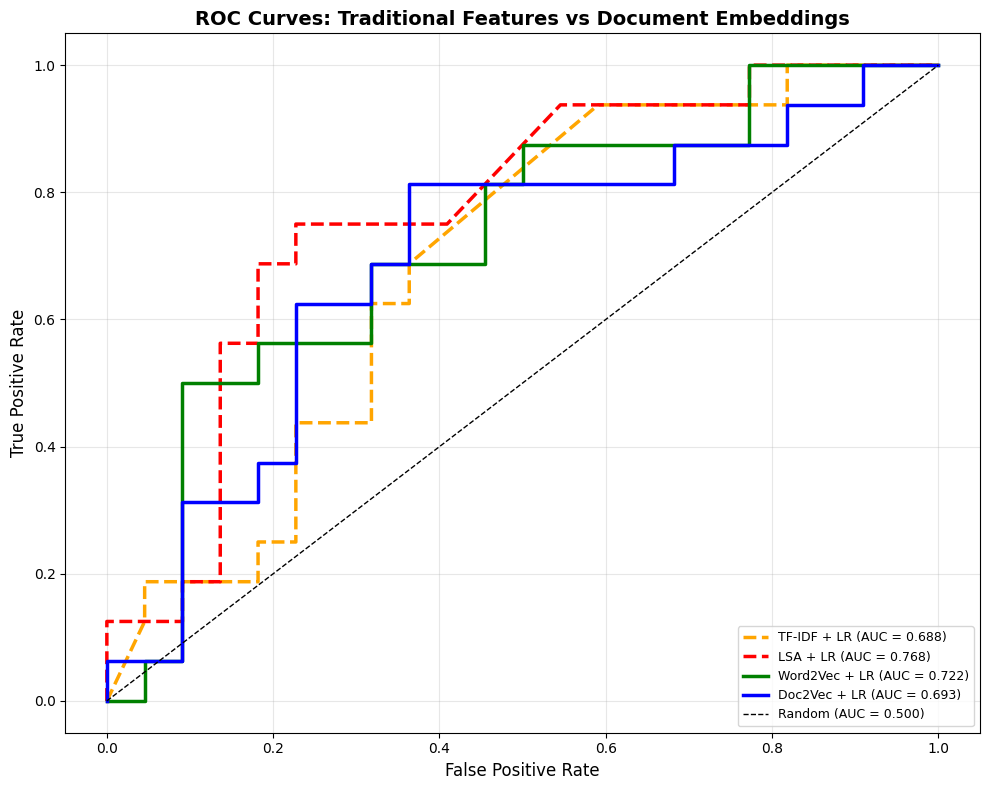

In [66]:
import matplotlib.pyplot as plt

# Calculate ROC curves for Logistic Regression models
fpr_w2v_lr, tpr_w2v_lr, _ = roc_curve(y_test, y_pred_prob_w2v_lr)
fpr_d2v_lr, tpr_d2v_lr, _ = roc_curve(y_test, y_pred_prob_d2v_lr)

# Plot ROC curves - comparing all Logistic Regression approaches
plt.figure(figsize=(10, 8))

# Traditional features
plt.plot(fpr_tfidf_lr, tpr_tfidf_lr, label=f'TF-IDF + LR (AUC = {auc_tfidf_lr:.3f})', 
         linewidth=2.5, linestyle='--', color='orange')
plt.plot(fpr_lsa_lr, tpr_lsa_lr, label=f'LSA + LR (AUC = {auc_lsa_lr:.3f})', 
         linewidth=2.5, linestyle='--', color='red')

# Embedding features
plt.plot(fpr_w2v_lr, tpr_w2v_lr, label=f'Word2Vec + LR (AUC = {auc_w2v_lr:.3f})', 
         linewidth=2.5, color='green')
plt.plot(fpr_d2v_lr, tpr_d2v_lr, label=f'Doc2Vec + LR (AUC = {auc_d2v_lr:.3f})', 
         linewidth=2.5, color='blue')

# Reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: Traditional Features vs Document Embeddings', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Key Insights:**
- **Logistic Regression with LSA** has the best overall performance. Since singular vectors are orthogonal uncorrelated components by default, which often benefits linear models. 
- Doc2Vec has a performance that is slightly better than TF-IDF. Probably because the dataset is to small to learn meaningful paragraph vectors and then their rich semantic advantage over TF-IDF is gone. 